In [13]:
%%capture
%pip install -r requirements.txt 

In [14]:
st_petersburg_incart_12lead_arrhythmia_database_path = r'data/china-12lead-ecg-challenge-database'
ptbxl_electrocardiography_database_path = r'data/ptbxl_electrocardiography_database'
ptb_diagnostic_ecg_database_path = r'data/ptb_diagnostic_ecg_database'
china_physiological_signal_challenge_in_2018_path = r'data/china_physiological_signal_challenge_2018'
china_12lead_ecg_challenge_database_path = r'data/china_12lead_ecg_challenge_database'
physionet_snomed_mappings_path = r'data/physionet_snomed_mappings'
physionet_challenge_models_path = r'datas/physionet_challenge_models'
georgia_12lead_ecg_challenge_database_path = r'data/georgia_12lead_ecg_challenge_database'
physionet_challenge_utility_script_path = r'notebooks/physionet_challenge_utility_script_patched_v2.py'

In [15]:
# =========================
# Standard library imports
# =========================
import os
import sys
import itertools
import re
from pathlib import Path

# =========================
# Third-party libraries
# =========================
import numpy as np
import pandas as pd

# Plotting
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt

import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ecg_plot

# ML / DL
import tensorflow as tf
from keras.utils import plot_model
from keras.utils import pad_sequences

# Explainability
import timeshap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.utils import check_random_state

import sklearn
from sklearn.linear_model import LinearRegression

# SciPy
from scipy import optimize

# =========================
# Project-specific paths
# =========================
physionet_delineation_path = r"...\delineation.py"
physionet_faithfulness_path = r"...\delineation.py"
physionet_bridge_path      = r"...\bridge.py"

sys.path.append(os.path.dirname(physionet_delineation_path))
sys.path.append(os.path.dirname(physionet_faithfulness_path))
sys.path.append(os.path.dirname(physionet_bridge_path))

# If defined elsewhere, ensure this path is on sys.path
physionet_challenge_utility_script_path = r"...\physionet_challenge_utility_script_patched_v2.py"
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))
import physionet_challenge_utility_script_patched_v2 as pc

# =========================
# Project-specific imports
# =========================
from delineation import lead_wave_table
from faithfulness import insertion_deletion_auc
from bridge import (
    find_ecg_batch,
    to_batch_L_T,
    make_keras_predict_fn,
    integrated_gradients_keras
)

# =========================
# (Optional) Jupyter autoreload
# =========================
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
MainPath = os.path.join(os.path.expanduser("~"), "Documents", "cvd-early-detection-ecg-uhull")

if os.path.isdir(MainPath):
    os.chdir(MainPath)
else:
    raise FileNotFoundError(MainPath)

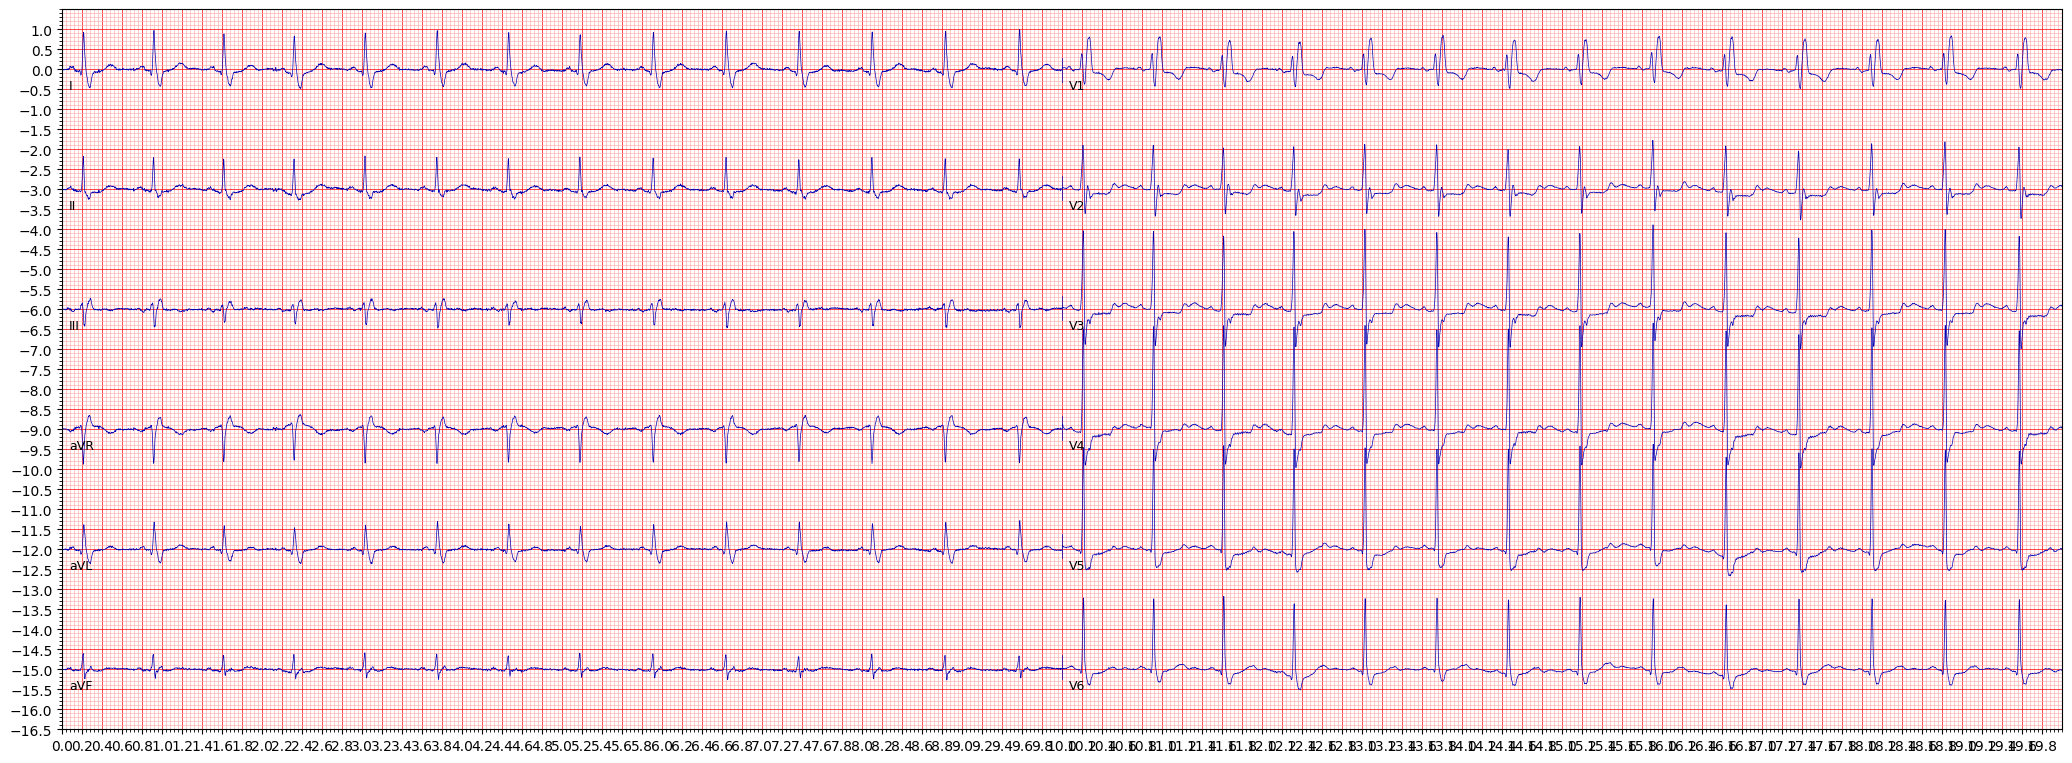

In [17]:
def plot_ecg(path):
    ecg_data = pc.load_challenge_data(path)
    ecg_plot.plot(ecg_data[0]/1000, sample_rate=500, title='')
    ecg_plot.show()

plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat") 

In [18]:
ecg_data = pc.load_challenge_data("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")
ecg_data[0].shape

(12, 5000)

### Methods


#### Data
The training data in this study contains 43,101 Electrocariographic recordings from 4 different sources. 
1. Southeast University, China, including the data from the China Physiological Signal Challenge 2018 (2 datasets from this source)
2. St. Petersburg Institute of Cardiological Technics, St. Petersburg, Russia.
3. The Physikalisch Technische Bundesanstalt, Brunswick, Germany. (2 datasets from this source)
4. Georgia 12-Lead ECG Challenge Database, Emory University, Atlanta, Georgia, USA.

The data is given in the form of native Python waveform-database-format [WFDB](https://wfdb.readthedocs.io/en/latest/). The dataset contains two file types:


1.   Header files (.hea)
2.   Signal files (.mat)

We have 43,101 Signal file with a corresponding header file. Each file are named with a patient number starting with ***A0001*** and goes all the way up to ***A6877***


#### From the header file we have access to gender and age from each patient

In [19]:
SEX_RE = re.compile(r'(?i)#\s*sex\s*:\s*([A-Za-z?]+)')
AGE_RE = re.compile(r'(?i)#\s*age\s*:\s*([0-9]+|NaN|\?)')
DX_RE  = re.compile(r'(?i)#\s*dx\s*:\s*(.+)$')

def coerce_age(val):
    if val is None:
        return None
    v = val.strip()
    if v.lower() in {"nan", "?", ""}:
        return None
    try:
        return int(v)
    except ValueError:
        # sometimes age can be float-looking; try float -> int
        try:
            return int(float(v))
        except Exception:
            return None

def normalize_sex(val):
    if not val:
        return None
    v = val.strip().upper()
    # common encodings: M/F, Male/Female, U/?, etc.
    if v in {"M", "MALE"}:
        return "M"
    if v in {"F", "FEMALE"}:
        return "F"
    return None  # Unknown/other -> None (or return v if you want to keep)

def parse_header(hea_path: Path):
    sex = age = label = None
    signal_len = None
    fs = None

    with open(hea_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    if not lines:
        return sex, age, label, signal_len, fs

    # First line usually like: "<recname> <n_sig> <fs> <nsamp> <date> <time>"
    first = lines[0].strip()
    parts = first.split()
    if len(parts) >= 4:
        # parts[2] = fs, parts[3] = number of samples
        try:
            fs = int(float(parts[2]))
        except Exception:
            fs = None
        try:
            signal_len = int(parts[3])
        except Exception:
            signal_len = None

    # Now scan ALL lines for comment metadata
    for raw in lines:
        ln = raw.strip()
        if not ln.startswith("#"):
            continue

        m = SEX_RE.search(ln)
        if m and sex is None:
            sex = normalize_sex(m.group(1))

        m = AGE_RE.search(ln)
        if m and age is None:
            age = coerce_age(m.group(1))

        m = DX_RE.search(ln)
        if m and label is None:
            # Keep the raw label string; or split to list if you prefer
            label = m.group(1).strip()

    return sex, age, label, signal_len, fs

CSV_CACHE = r"notebooks\finalproject\ecg_index.csv"

def build_index(root, cache_path=CSV_CACHE):
    """
    Scan dataset and build a CSV index with ECG metadata.
    """
    rows = []
    root = Path(root)

    for mat_path in sorted(root.rglob("*.mat")):
        hea_path = mat_path.with_suffix(".hea")
        if not hea_path.exists():
            continue

        _, header_data = pc.load_challenge_data(str(mat_path))

        # mimic original parsing
        label  = header_data[15][5:-1]
        gender = header_data[14][6:-1]
        age    = header_data[13][6:-1]

        # try to grab fs and signal length from first line
        fs = siglen = duration = None
        try:
            parts = header_data[0].split()
            if len(parts) >= 4:
                fs = int(float(parts[2]))
                siglen = int(parts[3])
                duration = siglen / fs if (fs and siglen) else None
        except Exception:
            pass

        rows.append({
            "mat": str(mat_path),
            "hea": str(hea_path),
            "sex": gender,
            "age": age,
            "label": label,
            "signal_len": siglen,
            "fs": fs,
            "duration_sec": duration,
        })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


In [20]:
REQUIRED_COLS = {"sex", "age", "label", "signal_len", "fs", "mat"}
CSV_CACHE = Path(r"notebooks\finalproject\ecg_index.csv")

def _load_metadata(cache_path: Path):
    df = pd.read_csv(cache_path)
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Cache missing required columns: {missing}")
    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )

def _auto_detect_root():
    # Try a few common places for the dataset
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "data",
        cwd / "datasets",
        cwd.parent,
        cwd.parent / "data",
    ]
    for c in candidates:
        try:
            next(c.rglob("*.mat"))
            return c
        except StopIteration:
            continue
    return None

def get_or_build_ecg_metadata(root: str | Path = None,
                                cache_path: str | Path = CSV_CACHE,
                                force_rebuild: bool = False):
    """
    Return (sex, age, label, signal_len, fs, ecg_filenames).
    If cache exists/valid, read it. Otherwise, scan and build it.
    If root is None, attempt to auto-detect a dataset root.
    """
    cache_path = Path(cache_path)
    if not force_rebuild and cache_path.exists():
        return _load_metadata(cache_path)

    if root is None:
        root = _auto_detect_root()
        if root is None:
            raise RuntimeError(
                "Could not auto-detect dataset root (no .mat files found in common locations). "
                "Pass root=... explicitly."
            )
    root = Path(root)

    # Ensure cache dir exists
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    # Build CSV via your existing scanner
    df = build_index(root, cache_path=cache_path)

    # Normalize some fields
    if "age" in df.columns:
        df["age"] = df["age"].apply(coerce_age)
    if "sex" in df.columns:
        df["sex"] = df["sex"].apply(normalize_sex)
    for col in ["signal_len", "fs"]:
        if col not in df.columns:
            df[col] = None

    df.to_csv(cache_path, index=False)

    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )


In [21]:
CSV_CACHE = Path(r"notebooks\finalproject\ecg_index.csv")

sex, age, labels, signal_len, fs, ecg_filenames = get_or_build_ecg_metadata(cache_path=CSV_CACHE)

#### From the figure under we can se that the signals varies, but most of the signals are around 5000 samples long

In [22]:
# Load CSV
df = pd.read_csv(CSV_CACHE)

def plot_signal_lengths(df, title):
    signal_count = df["signal_len"].value_counts()

    plt.figure(figsize=(20, 10))
    plt.title(title, fontsize=36)
    sns.barplot(x = signal_count[:10].index, y = signal_count[:10].values)
    plt.xlabel("Signal length (samples)", fontsize=18)
    plt.ylabel("Count", fontsize=18)
    plt.show()


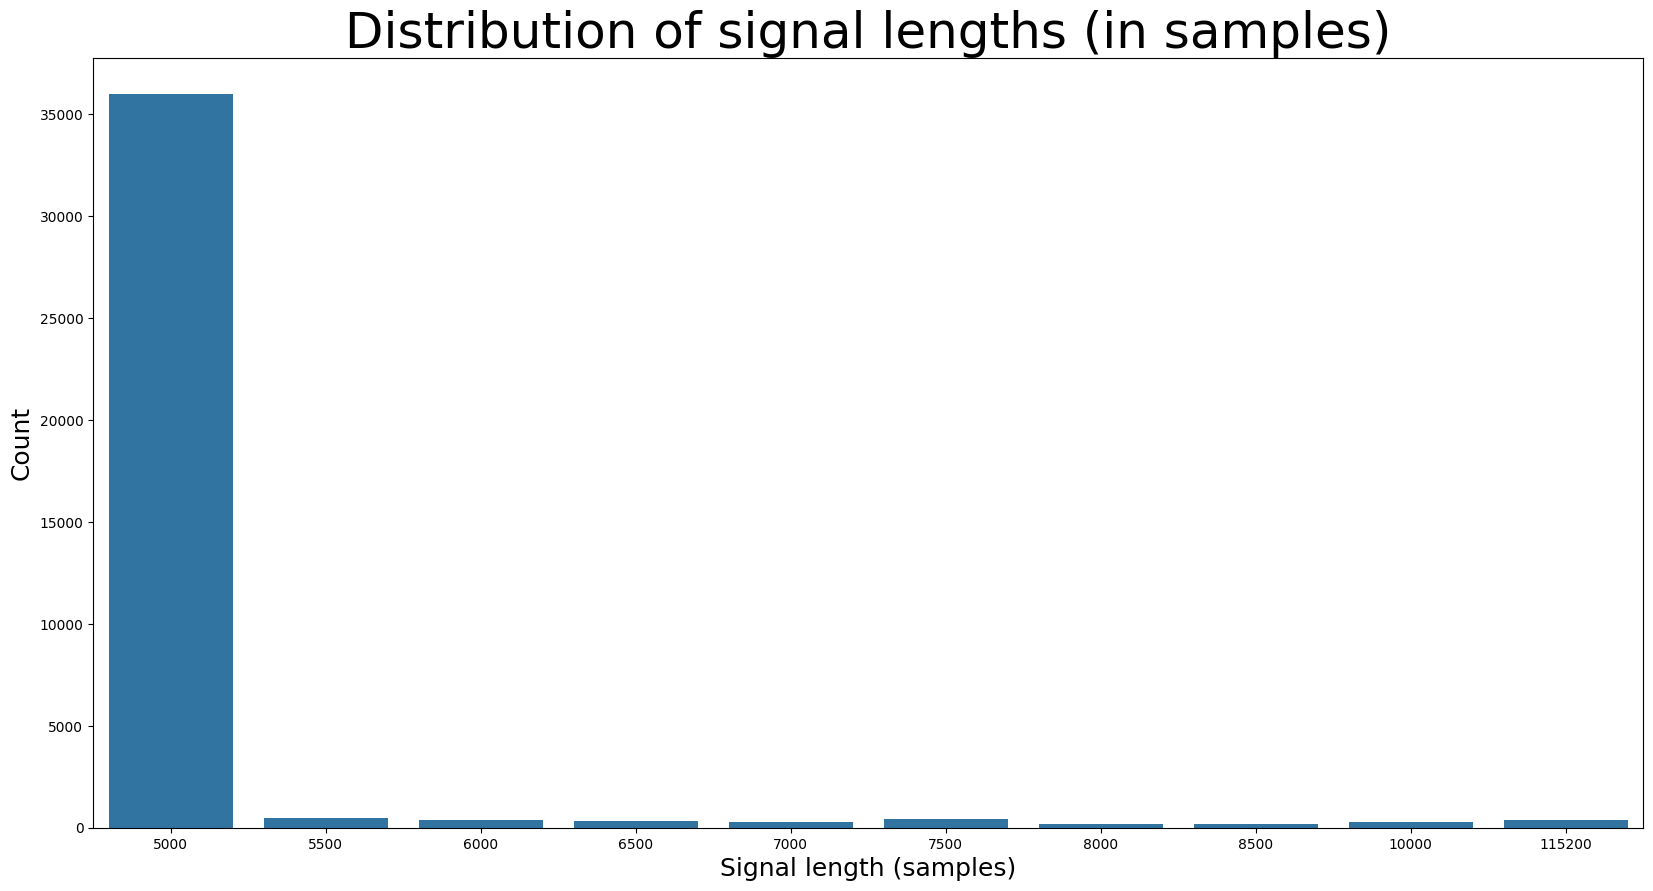

In [23]:
plot_signal_lengths(df, "Distribution of signal lengths (in samples)")

#### All diagnoses are encoded with SNOMED-CT codes. We need a CSV-file to decode them:

In [24]:
SNOMED_scored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_unscored.csv", sep=";")

df_labels = pc.make_undefined_class(labels, SNOMED_unscored)

In [25]:
print(df_labels)

                                                       0
0                              undefined class,427084000
1                                        undefined class
2                        undefined class,undefined class
3                        undefined class,undefined class
4                                        undefined class
...                                                  ...
43096    undefined class,undefined class,undefined class
43097  undefined class,undefined class,427084000,unde...
43098  undefined class,undefined class,426627000,6359...
43099  undefined class,427084000,undefined class,unde...
43100  undefined class,426627000,undefined class,unde...

[43101 rows x 1 columns]


#### To be able to feed the labels to a Neural Network we need to OneHot encode the labels

In [26]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '17338001' '251146004' '270492004' '284470004'
 '39732003' '426177001' '426627000' '426783006' '427084000' '427172004'
 '427393009' '445118002' '47665007' '59118001' '59931005' '63593006'
 '698252002' '713426002' '713427006' 'undefined class']
classes: 27


In [27]:
snomed_abbr = []
for j in range(len(snomed_classes)):
    for i in range(len(SNOMED_scored.iloc[:,1])):
        if (str(SNOMED_scored.iloc[:,1][i]) == snomed_classes[j]):
            snomed_abbr.append(SNOMED_scored.iloc[:,2][i])
            
snomed_abbr = np.asarray(snomed_abbr)

#### The distribution of diagnoses accross the dataset
In the figure under we can see the same SNOMED CT codes decoded into human readable diagnoses on the X-axis. On the Y-axis we have the number of the given diagnoses in the dataset

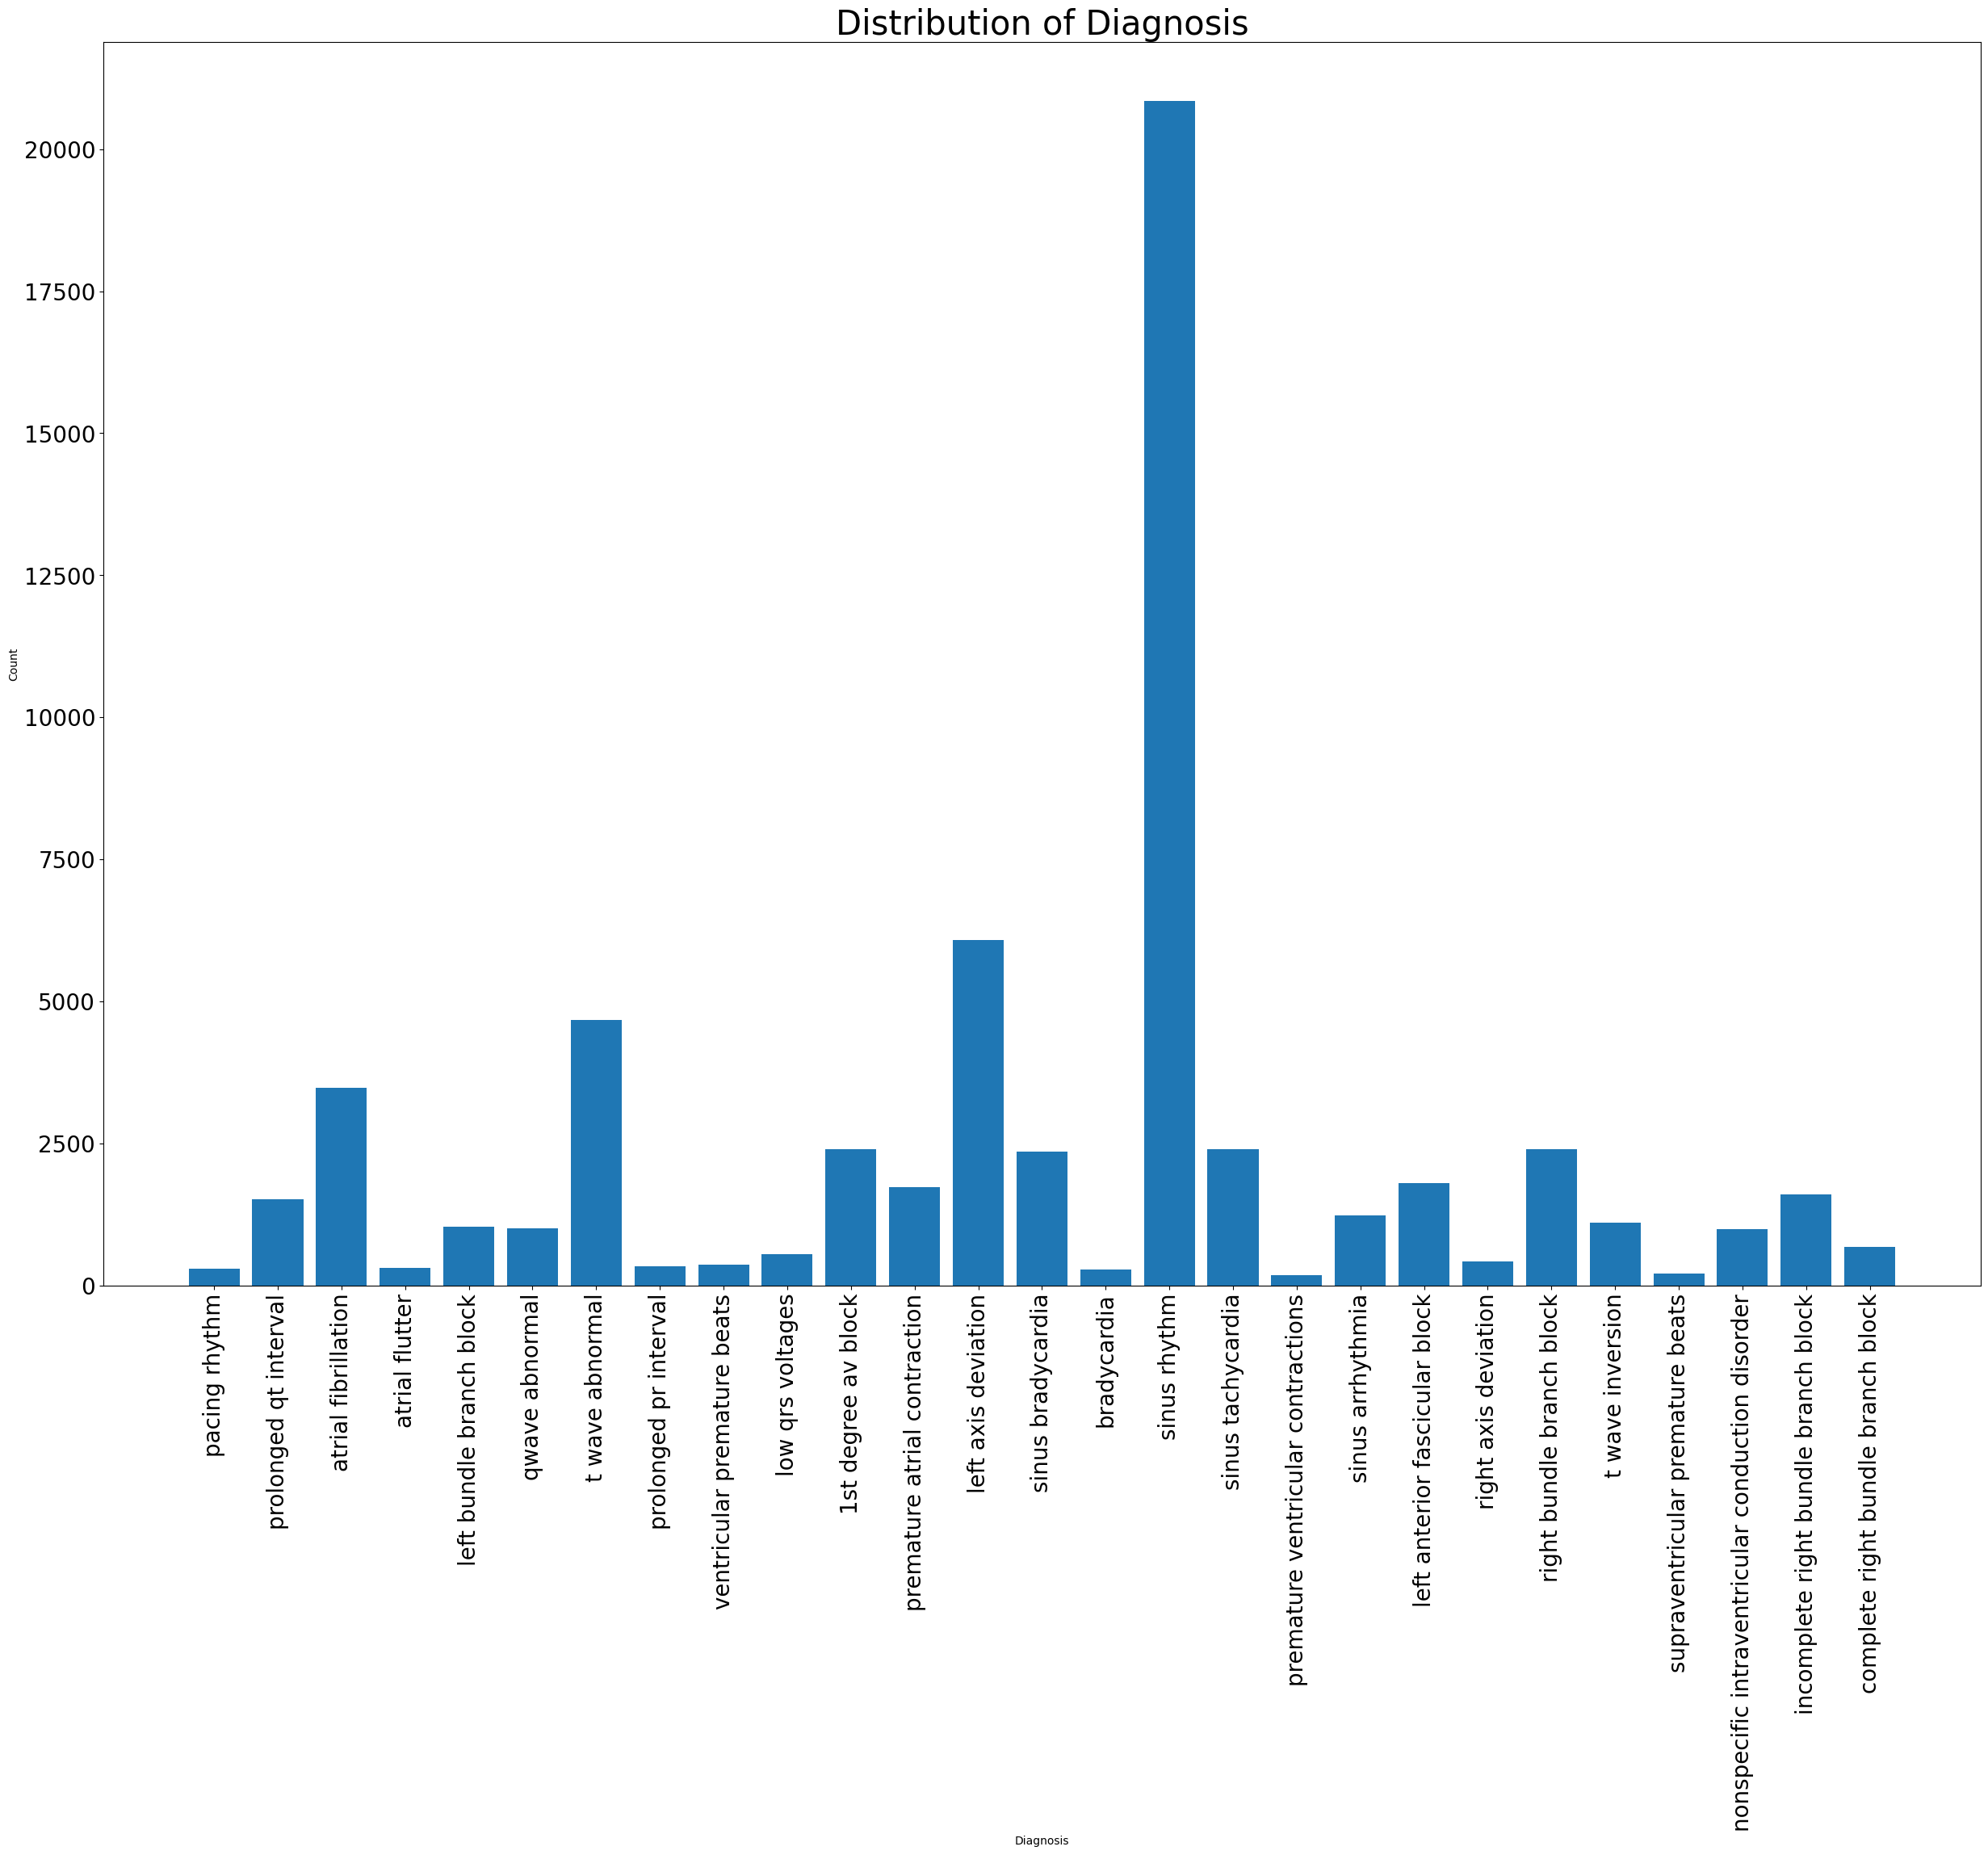

In [28]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

#### Since this is a multiclass multi-label classification there will be a lot of different combinations of the 27 diagnoses in this study

In [29]:
y_all_comb = pc.get_labels_for_all_combinations(y)
print("Total number of unique combinations of diagnosis: {}".format(len(np.unique(y_all_comb))))

Total number of unique combinations of diagnosis: 1414


#### We will split the data using a 10-fold split with Shuffle=True and random_seed = 42. 
The distribution of Training and Val data in each fold is now:
(in this study we only use the first fold for hold out validation)

In [30]:
folds = pc.split_data(labels, y_all_comb)

Training split: 38790
Validation split: 4311


C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=10.
  warnings.warn(


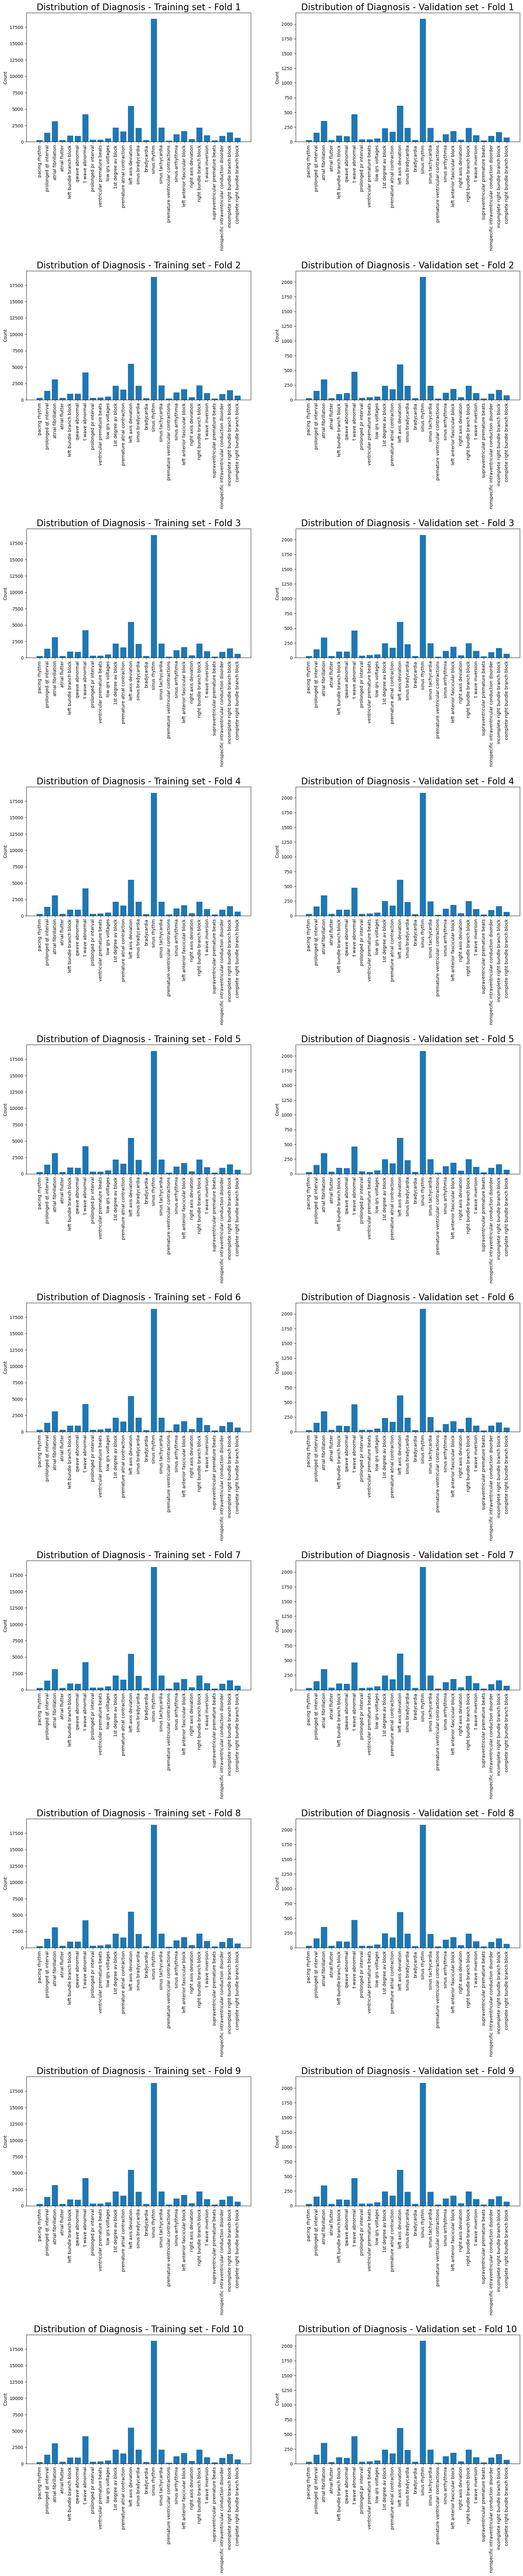

In [31]:
pc.plot_all_folds(folds,y,snomed_classes)

#### Make Batch generators
To feed the Neural Network with a dataset that is too large for our RAM set we need a batch generator to get data into the RAM in batches.
We start by making a "order array" so we can shuffle the order of the data during the training process

In [32]:
order_array = folds[0][0]

In [33]:
def shuffle_batch_generator_demo(batch_size, gen_x,gen_y, gen_z): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    batch_demo_data = np.zeros((batch_size,2))
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            batch_demo_data[i] = next(gen_z)

        X_combined = [batch_features, batch_demo_data]
        yield X_combined, batch_labels
        
def shuffle_batch_generator(batch_size, gen_x,gen_y): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            
        yield batch_features, batch_labels

def generate_y_shuffle(y_train):
    while True:
        for i in order_array:
            y_shuffled = y_train[i]
            yield y_shuffled

def generate_X_shuffle(X_train):
    while True:
        for i in order_array:
                #if filepath.endswith(".mat"):
                    data, header_data = pc.load_challenge_data(X_train[i])
                    X_train_new = pad_sequences(data, maxlen=5000, truncating='post',padding="post")
                    X_train_new = X_train_new.reshape(5000,12)
                    yield X_train_new

def generate_z_shuffle(age_train, gender_train):
    while True:
        for i in order_array:
            gen_age = age_train[i]
            gen_gender = gender_train[i]
            z_train = [gen_age , gen_gender]
            yield z_train

#### Imbalanced data
To compensate for the imbalaced data we calculate a weight for each label. The weight decides how much the Neural Network will learn from the different data labels

In [34]:
new_weights=pc.calculating_class_weights(y)

In [35]:
keys = np.arange(0,27,1)
weight_dictionary = dict(zip(keys, new_weights.T[1]))
weight_dictionary

{0: 72.0752508361204,
 1: 14.243555849306015,
 2: 6.201582733812949,
 3: 68.63216560509554,
 4: 20.701729106628243,
 5: 21.273938795656466,
 6: 4.611705542478066,
 7: 63.383823529411764,
 8: 59.04246575342466,
 9: 38.759892086330936,
 10: 9.00187969924812,
 11: 12.464141122035858,
 12: 3.5409957279000985,
 13: 9.13543874523103,
 14: 74.828125,
 15: 1.0337954523649622,
 16: 8.971898417985013,
 17: 114.63031914893617,
 18: 17.379435483870967,
 19: 11.932724252491694,
 20: 50.469555035128806,
 21: 8.971898417985013,
 22: 19.379946043165468,
 23: 100.23488372093023,
 24: 21.615346038114343,
 25: 13.37709497206704,
 26: 31.552708638360176}

#### Learning rate reduction
To controll the learning rate we use learning rate reduction and early stopping to prevent overfitting

In [36]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC', factor=0.1, patience=1, verbose=1, mode='max',
    min_delta=0.0001, cooldown=0, min_lr=0
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_AUC', mode='max', verbose=1, patience=2)

#### To find the optimal threshold we will use Downhill simplex method

In [37]:
def thr_chall_metrics(thr, label, output_prob):
    return -pc.compute_challenge_metric_for_opt(label, np.array(output_prob>thr))

### Results

#### Residual Neural Network

In [38]:
model = pc.residual_network_1d()

load a pre-trained model

In [39]:
model.load_weights("data/physionet-challenge-models/resnet_model.h5")

In [40]:
ecg_filenames = np.asarray(ecg_filenames, dtype=object)
y_pred = model.predict(x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0])

135/135 [==============================] - 102s 754ms/step


In [41]:
init_thresholds = np.arange(0, 1, 0.05)

In [42]:
all_scores = pc.iterate_threshold(y_pred, ecg_filenames, y, folds[0][1])

0.1516625863156977
0.3257728585224567
0.34907885319229215
0.28868950738443655
0.181260365067383
0.07488523992867367
-0.030592151530913974
-0.13422631975369734
-0.2242114341113018
-0.3122581976641526
-0.3953465808086114
-0.47448587178946944
-0.5439621181557601
-0.6015332151710997
-0.6651141368699174
-0.7092221508645785
-0.7470735743049693
-0.7760926050516812
-0.8006819928304572
-0.8173020165059404


In [43]:
new_best_thr = optimize.fmin(thr_chall_metrics, 
                                args = (pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1], y_pred), 
                                x0 = init_thresholds[all_scores.argmax()] * np.ones(27))

Optimization terminated successfully.
         Current function value: -0.380630
         Iterations: 302
         Function evaluations: 579


In [44]:
print(pc.compute_challenge_metric_for_opt(pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1],(y_pred>new_best_thr)*1))

0.38063028434382484


Make conf.matrix

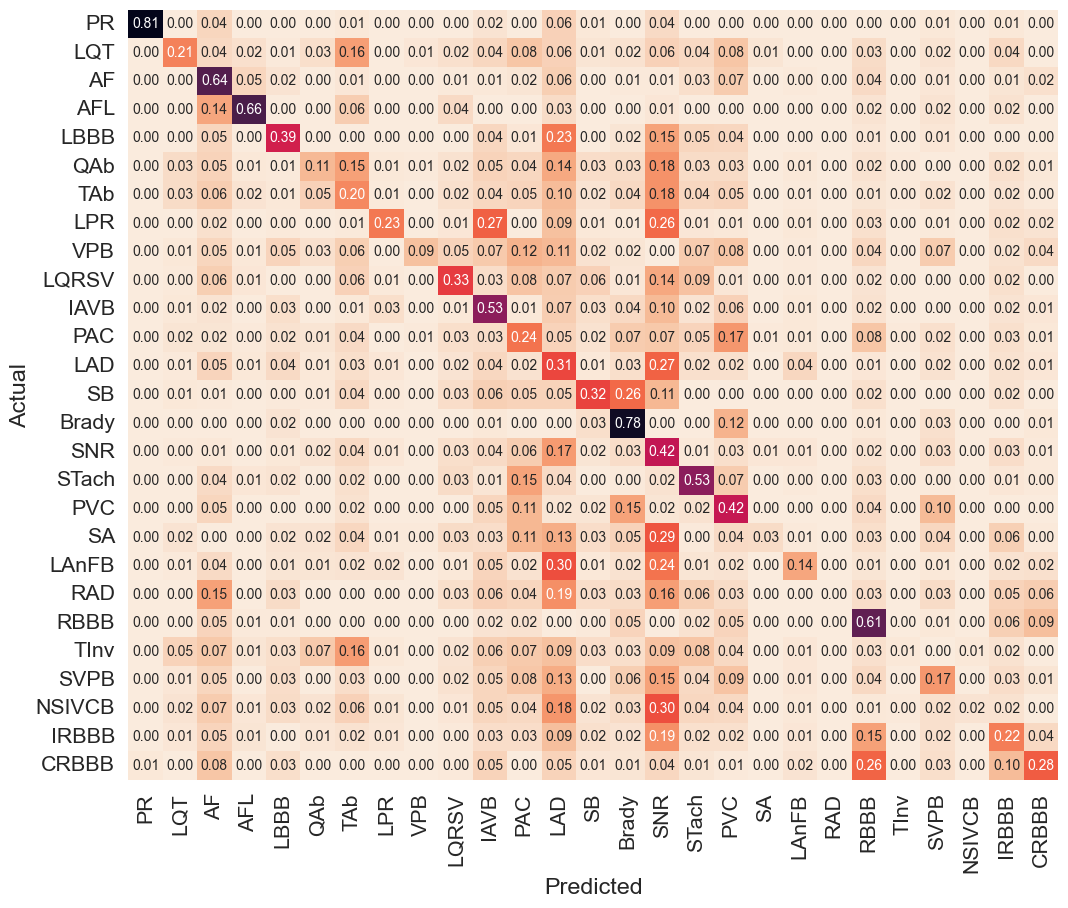

In [45]:
pc.plot_normalized_conf_matrix(y_pred, ecg_filenames, y, folds[0][1], new_best_thr, snomed_classes, snomed_abbr)
plt.savefig("confusion_matrix_resnet.png", dpi=100)

In [46]:
test_aa = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0]
print(test_aa.shape)

(4311, 5000, 12)


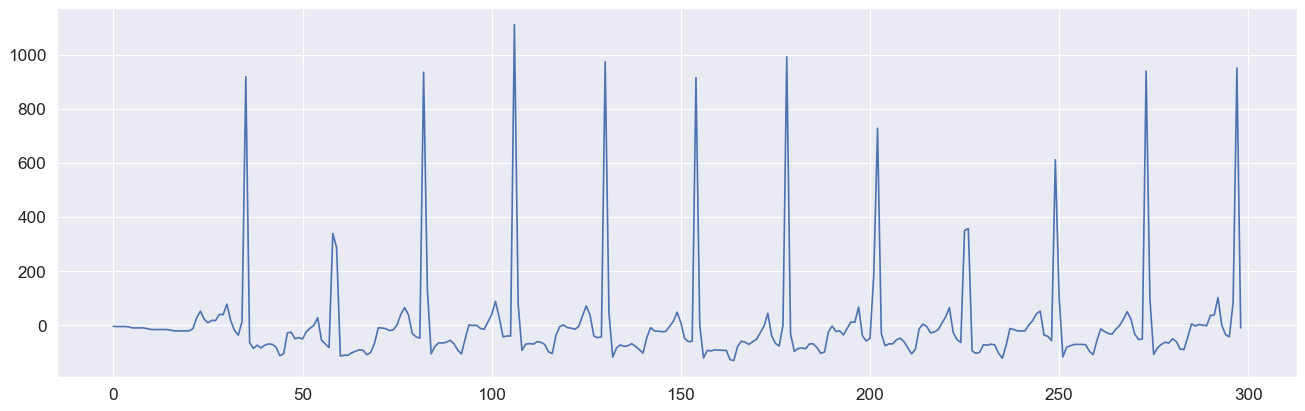

In [47]:
figure(figsize=(20, 6), dpi=80)
plt.plot(test_aa[0,1:300,1])

In [48]:
y_pred.shape

(4311, 27)

In [49]:
test_aa[:2,:,:].shape

(2, 5000, 12)

In [50]:
sample = np.array(test_aa[0:10]).copy()
sample.shape

(10, 5000, 12)

## Class implementation

In [51]:
class Telmi:
    def __init__(self,model,data,num_perturbations: int,window_size:int, kernel_width=0.25):
        self.model = model
        self.data = data
        self.num_perturbations = num_perturbations
        self.window_size = window_size
        self.kernel_width = kernel_width
        self.num_features = data.shape[2]
        if len(data.shape) != 3:
            raise ValueError("input Data must be batch of instance")

    def _kernel_func(self, distances):
        return np.sqrt(np.exp(-(distances ** 2) / self.kernel_width ** 2))

    def _instance_feature_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,self.num_features)
        perturb_instance_predictions = np.array([model.predict(subset * instance) for subset in perturbations_sets])
        original_instance = np.ones(self.num_features)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_instance_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]
    
    def _instance_event_explain(self, instance):
        instance = np.array([instance])
        top_class = model.predict(instance)[0].argsort()
        num_events = int(np.ceil(instance.shape[1] / self.window_size))
        events = list(self._create_event_chunks(instance[0].copy(),num_events))
        perturbations_sets = self._create_perturbations_sets(self.num_perturbations,num_events)
        perturb_events_predictions = []
        for subset in perturbations_sets:
            perturb_events = np.array(list(map(lambda x:x[0] * x[1], zip(events,subset))))
            perturb_events_predictions.append(model.predict(perturb_events))
        perturb_events_predictions = np.array(perturb_events_predictions)
        original_instance = np.ones(num_events)[np.newaxis,:]
        distances = sklearn.metrics.pairwise_distances(perturbations_sets,original_instance, metric='cosine').ravel()
        weights = self._kernel_func(distances)
        surrogate_model = LinearRegression()
        surrogate_model.fit(perturbations_sets, perturb_events_predictions[:,:,top_class[-1]], sample_weight=weights)
        return surrogate_model.coef_[0]

    def feature_explain(self):
        return np.array(list(map(self._instance_feature_explain,self.data)))
    
    def event_explain(self):
        return np.array(list(map(self._instance_event_explain,self.data)))
    
    @staticmethod
    def _create_perturbations_sets(m: int, n: int):
        perturbations_sets = list(map(list, itertools.product([0, 1], repeat=n)))
        if m==-1 or m==2**n:
            return np.array(perturbations_sets)
        random_index = np.random.choice(len(perturbations_sets), m, replace=False)
        random_perturbations_sets = [perturbations_sets[i] for i in random_index]
        return np.array(random_perturbations_sets)

    @staticmethod
    def _create_event_chunks(instance, num_chunks: int):
        for i in range(0, len(instance), num_chunks):
            yield instance[i:i+num_chunks]   


In [52]:
x = Telmi(model,sample,200,500)

In [53]:
x.feature_explain()

1/1 [==============================] - 0s 48ms/step


array([[ 2.85501934e-02,  4.29212191e-02,  4.72649261e-02,
         2.10030387e-02,  4.49304342e-02,  4.44673637e-02,
         3.06023831e-02,  3.46323980e-02,  1.02859258e-01,
        -5.26477194e-03,  6.25719550e-02,  6.19881022e-02],
       [-2.26996937e-03, -3.78922567e-03, -2.93897385e-03,
         5.52830816e-03, -1.45173731e-03,  4.79503980e-03,
        -1.87583383e-03,  3.30218800e-03, -3.81643273e-03,
         6.75401119e-03,  2.48360240e-03,  6.69452923e-04],
       [-6.30501062e-03, -2.47952744e-04,  3.56360785e-03,
         2.78658915e-02,  8.50601520e-03,  2.57489832e-02,
        -7.27364560e-03,  1.23048178e-02, -3.37327414e-03,
         2.05472003e-02, -4.41153856e-04,  4.05287122e-03],
       [-3.57766179e-05, -2.87438394e-05, -6.58455044e-04,
         4.28656807e-04, -1.32140807e-04,  7.16632873e-05,
        -1.00582778e-03,  3.12444374e-04, -1.50502958e-03,
         5.07996461e-04,  3.19028507e-04, -4.83622024e-04],
       [ 1.41745854e-02,  6.60983913e-02,  1.8677368

In [54]:
x.event_explain()

1/1 [==============================] - 0s 22ms/step


array([[-8.13917504e-05, -2.88002448e-21,  2.23777662e-20,
         1.17612601e-20, -1.56899798e-20, -4.56362400e-21,
        -1.24038843e-20,  1.17826509e-20, -5.34999252e-21,
         2.30249321e-20],
       [-2.13852551e-01, -1.50583989e-16, -5.45769530e-17,
        -2.69983444e-17, -1.03771237e-16, -5.13099354e-17,
         2.64141584e-17,  1.40591301e-16, -3.04126264e-17,
        -1.26150545e-16],
       [ 3.54288518e-03, -1.00520907e-18, -5.78784697e-19,
         2.23329085e-19,  1.37142610e-18, -1.70050946e-18,
        -2.54856026e-19,  7.80937544e-19, -1.38586124e-18,
         6.59024449e-19],
       [ 7.75011750e-02,  4.09682517e-18,  1.74853683e-17,
        -3.07942695e-17, -2.15480000e-17,  1.05151801e-17,
         2.00334599e-17, -2.05931745e-17, -2.49352576e-18,
         4.34450889e-19],
       [ 4.40487154e-02, -1.42149494e-16,  5.14507893e-17,
        -4.71302918e-17, -2.16794846e-16, -5.63582997e-17,
         5.71198376e-17,  7.01720755e-17,  2.02898027e-16,
         1.

## Feature explain

In [55]:
sample_prediction = model.predict(sample)

1/1 [==============================] - 0s 220ms/step


In [56]:
top_classes = sample_prediction[0].argsort()

In [57]:
top_classes

array([13,  7,  0,  9, 26, 10, 19,  3,  4, 20,  2, 12, 18, 14, 25, 21, 15,
        1, 24, 23,  8, 22,  6,  5, 17, 11, 16], dtype=int64)

In [58]:
num_perturbations = 200
num_feature = 12
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 1, 0],
       [1, 0, 1, ..., 1, 1, 1],
       ...,
       [0, 1, 0, ..., 1, 0, 0],
       [1, 1, 0, ..., 0, 1, 1],
       [0, 1, 0, ..., 0, 1, 1]])

In [59]:
perturb_prediction = []
distance = []
for subset in perturbations:
    data = sample * subset
    perturb_prediction.append(model.predict(data))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 261ms/step


In [60]:
perturb_prediction.shape


(200, 10, 27)

In [61]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [62]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [63]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([ 0.01522964,  0.05708526,  0.07178014,  0.00469928,  0.02971278,
        0.0432023 , -0.03210386, -0.01702963,  0.07594188,  0.05701875,
        0.03975136,  0.04004366])

In [64]:
Coeff_df = pd.DataFrame()

Coeff_df['TELMI'] = coeff

fig = px.bar(Coeff_df, x=Coeff_df['TELMI'], y= Coeff_df.index, orientation='h', color=Coeff_df.index)
fig.show()

In [65]:
fig = go.Figure(go.Waterfall(
    name = "20", 
    orientation = "h",
    x = Coeff_df['TELMI'],
    textposition = "outside",
    y = Coeff_df['TELMI'].index,    
    connector = {"line":{"color":"rgb(63, 63, 63)"}},
))

fig.update_layout(
        title = "TELMI Explanability",
        showlegend = True
)

fig.show()

## event explain

In [66]:
sample = np.array([test_aa[0]])

In [67]:
num_perturbations = 200
num_feature = 10
perturbations = np.random.binomial(1, 0.5, size=(num_perturbations, num_feature))
perturbations

array([[0, 1, 1, ..., 1, 1, 0],
       [1, 0, 1, ..., 0, 1, 0],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 1, 0, 0],
       [1, 1, 1, ..., 1, 0, 0]])

In [68]:
reshaped_sample = sample.reshape((5000,12)).copy()

In [69]:
perturb_prediction = []
distance = []
for subset in perturbations:
    reshaped_sample = sample.reshape((5000,12)).copy()
    splited_event = np.array_split(reshaped_sample,10)
    for idx, value in enumerate(subset):
        if value == 0:
            splited_event[idx][:,:] = 0
    perturb_prediction.append(model.predict(np.array(splited_event)))
perturb_prediction = np.array(perturb_prediction)

1/1 [==============================] - 0s 49ms/step


In [70]:
original_instance = np.ones(num_feature)[np.newaxis,:]
distances = sklearn.metrics.pairwise_distances(perturbations,original_instance, metric='cosine').ravel()
distances.shape

(200,)

In [71]:
kernel_width = 0.25
weights = np.sqrt(np.exp(-(distances**2)/kernel_width**2))
weights.shape

(200,)

In [72]:
class_to_explain = top_classes[-1]
surrogate_model = LinearRegression()
surrogate_model.fit(X=perturbations, y=perturb_prediction[:,:,class_to_explain], sample_weight=weights)
coeff = surrogate_model.coef_[0]
coeff

array([ 1.63374348e-01, -8.17982257e-17,  5.00628751e-17,  7.11553805e-17,
        7.22746048e-17, -2.68903045e-17, -1.80431741e-17,  4.88078562e-17,
        4.14875406e-17, -1.11411719e-17])

### TimeSHAP

In [86]:
def prepare_ecg(filepath, maxlen=5000):
    data, header = pc.load_challenge_data(filepath)  # shape: (12, variable_length)
    data = np.array(data).T  # shape: (length, 12)
    data = pad_sequences([data], maxlen=maxlen, padding='post', truncating='post', dtype='float32')  # shape: (1, maxlen, 12)
    return data

In [114]:
from timeshap.wrappers import TorchModelWrapper
model_wrapped = TorchModelWrapper(model)
f_hs = lambda x, y=None: model_wrapped.predict_last_hs(x, y)

In [ ]:
from timeshap.utils import calc_avg_event

X = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0]

X_2d = X.mean(axis=1) if X.ndim == 3 else X   # -> (4311, 12)

lead_names = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']  # example; replace with yours
assert len(lead_names) == X_2d.shape[1]

df_feat = pd.DataFrame(X_2d, columns=lead_names)

average_event = calc_avg_event(
    df_feat,
    numerical_feats=lead_names,     # names of the 12 inputs
    categorical_feats=[],
    model_features=lead_names       # must match the DataFrame column order
)


In [116]:
average_event

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-0.6022,-0.589,-0.5694,-0.5728,-0.574,-0.564,-0.568,-0.5754,-0.6016,-0.5728,-0.5852,-0.5968


In [111]:
import numpy as np
import pandas as pd
from pathlib import Path
from timeshap.utils import calc_avg_sequence

# Your existing inputs
X = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0]  # X has shape (N, T, F) or (N, F)
val_idx = folds[0][1]                                              # indices used for the validation subset
files_sub = np.asarray(ecg_filenames)[val_idx]                     # subset files aligned with X

# Make sequence IDs from the subset (drop dirs/extensions if you like)
sequence_ids = np.array([Path(str(p)).stem for p in files_sub])

if X.ndim == 3:
    N, T, F = X.shape
    assert len(sequence_ids) == N
    df_feat = pd.DataFrame(X.reshape(N*T, F))
    df_feat["sequence_id"] = np.repeat(sequence_ids, T)
    df_feat["timestep"] = np.tile(np.arange(T), N)
    feature_idx = list(range(F))  # use indices; or provide lead_names if you have them in correct order
    entity_col = "sequence_id"

elif X.ndim == 2:
    N, F = X.shape
    assert len(sequence_ids) == N
    df_feat = pd.DataFrame(X)
    df_feat["sequence_id"] = sequence_ids
    feature_idx = list(range(F))
    entity_col = "sequence_id"

average_sequence = calc_avg_sequence(
    df_feat,
    numerical_feats=feature_idx,   # or lead_names if available and length==F
    categorical_feats=[],
    model_features=feature_idx,    # or lead_names
    entity_col=entity_col
)


In [112]:
average_sequence

array([[-20., -20., -20., ..., -20., -20., -20.],
       [-20., -19., -20., ..., -21., -21., -20.],
       [-19., -20., -20., ..., -19., -19., -19.],
       ...,
       [-26., -26., -28., ..., -29., -28., -27.],
       [-28., -27., -27., ..., -29., -29., -29.],
       [-29., -29., -29., ..., -29., -29., -29.]])

In [126]:
SEQ_LEN = 5000   # timesteps your model expects
NFEATS  = 12     # number of input features per timestep

# If multiclass, pick a class index to score (0..C-1). For binary set to None.
TARGET_CLASS = None  # e.g., 5 for a specific SNOMED class

def f_varlen(x, hs=None):
    """
    x: (N, t, NFEATS) variable-length sequences.
    Returns (pred, hs) where pred is (N, 1).
    """
    assert x.ndim == 3 and x.shape[2] == NFEATS, f"Expected (N, t, {NFEATS}), got {x.shape}"

    N, t, F = x.shape
    if t == SEQ_LEN:
        Xp = x
    elif t > SEQ_LEN:
        # truncate (adjust if your training kept last 5000)
        Xp = x[:, :SEQ_LEN, :]
    else:
        # pad with zeros (or repeat last step if that matches your preprocessing)
        pad = np.zeros((N, SEQ_LEN - t, F), dtype=x.dtype)
        # pad = np.repeat(x[:, -1:, :], SEQ_LEN - t, axis=1)  # alternative
        Xp = np.concatenate([x, pad], axis=1)

    y = model.predict(Xp, verbose=0)   # shape (N, 1) for binary, (N, C) for multiclass

    # Ensure the function returns a single score column (N,1)
    if y.ndim == 2 and y.shape[1] > 1:
        if TARGET_CLASS is None:
            raise ValueError(
                f"Model output has {y.shape[1]} classes. "
                f"Set TARGET_CLASS to the class index you want to score."
            )
        y = y[:, [TARGET_CLASS]]  # keep as (N,1)

    return y, None


In [131]:
import numpy as np
import pandas as pd
from timeshap.utils import get_avg_score_with_avg_event

# ---- Auto-detect model input shape (N, T, F) ----
try:
    # Keras Functional/Sequential: model.input_shape like (None, T, F)
    SEQ_LEN = int(model.input_shape[1])
    NFEATS  = int(model.input_shape[2])
except Exception:
    # Fallback (edit if your model differs)
    SEQ_LEN, NFEATS = 5000, 12

# ---- Ensure average_event is a 1D vector of input features (length = NFEATS) ----
avg_event_vec = np.asarray(average_event).ravel()
assert avg_event_vec.shape[0] == NFEATS, (
    f"average_event length {avg_event_vec.shape[0]} must equal NFEATS {NFEATS} "
    f"(your model’s input feature count)."
)

# ---- Wrapper that accepts variable-length sequences and returns (pred, hs) ----
# It uses a global/outer variable TARGET_CLASS to select one score column (N,1).
TARGET_CLASS = 0  # placeholder; will be overwritten inside the loop

import numpy as np

SEQ_LEN = 5000   # timesteps your model expects
NFEATS  = 12     # features per timestep
# TARGET_CLASS already set in your loop

def f_varlen(x, hs=None):
    """
    Accepts x in any of these shapes and normalises to (N, t, NFEATS):
      - (N, t, NFEATS)  -> as-is
      - (t, NFEATS)     -> add batch dim -> (1, t, NFEATS)
      - (NFEATS,)       -> single step -> (1, 1, NFEATS)
      - (1, NFEATS)     -> single step -> (1, 1, NFEATS)
    Pads/truncates to (N, SEQ_LEN, NFEATS), predicts, and returns (N,1).
    """
    x = np.asarray(x)

    if x.ndim == 3:
        Xn = x  # (N, t, F)
    elif x.ndim == 2:
        # Could be (t, F) or (1, F). Treat last dim as features if it matches NFEATS.
        if x.shape[-1] == NFEATS:
            Xn = x[None, ...]  # (1, t, F) or (1, 1, F)
        elif x.shape[0] == NFEATS:
            # Probably (F, t) -> transpose time to axis 0
            Xn = x.T[None, ...]  # (1, t, F)
        else:
            raise ValueError(f"Cannot infer (t,F) from shape {x.shape} with NFEATS={NFEATS}")
    elif x.ndim == 1:
        if x.shape[0] != NFEATS:
            raise ValueError(f"1D input length {x.shape[0]} != NFEATS {NFEATS}")
        Xn = x[None, None, :]  # (1, 1, F)
    else:
        raise ValueError(f"Unexpected x.ndim={x.ndim} for shape {x.shape}")

    # Now Xn is (N, t, NFEATS)
    N, t, F = Xn.shape
    assert F == NFEATS, f"Features dim mismatch: {F} != {NFEATS}"

    # Pad/truncate along time to SEQ_LEN (mirror your training scheme)
    if t == SEQ_LEN:
        Xp = Xn
    elif t > SEQ_LEN:
        Xp = Xn[:, :SEQ_LEN, :]     # or keep last SEQ_LEN: Xn[:, -SEQ_LEN:, :]
    else:
        pad = np.zeros((N, SEQ_LEN - t, F), dtype=Xn.dtype)
        # or repeat last step: pad = np.repeat(Xn[:, -1:, :], SEQ_LEN - t, axis=1)
        Xp = np.concatenate([Xn, pad], axis=1)

    y = model.predict(Xp, verbose=0)   # (N, C) with C=27
    y = y[:, [TARGET_CLASS]]           # -> (N, 1)
    return y, None

# ---- Compute average-score-over-length for ALL classes ----
all_avg_scores = {}
class_names = list(snomed_abbr)  # ensure it's a list

for i, name in enumerate(class_names):
    TARGET_CLASS = i  # update the class selected by f_varlen
    scores_i = get_avg_score_with_avg_event(
        f_varlen,
        avg_event_vec,   # 1D vector of length NFEATS
        top=60          # probe up to length 480 (adjust as you like)
    )
    # scores_i is a dict: {length: score}
    all_avg_scores[name] = scores_i

# ---- Optional: convert to a DataFrame for easy viewing/plotting ----
# Rows = sequence length, Columns = class names, Values = average score
df_avg_scores = pd.DataFrame(all_avg_scores).sort_index()

# Peek
print(df_avg_scores.head())


         PR       LQT        AF       AFL      LBBB       QAb      TAb  \
1  0.001375  0.012686  0.013562  0.034215  0.021204  0.024599  0.01877   
2  0.001375  0.012686  0.013562  0.034215  0.021204  0.024599  0.01877   
3  0.001375  0.012686  0.013562  0.034215  0.021204  0.024599  0.01877   
4  0.001375  0.012686  0.013562  0.034215  0.021204  0.024599  0.01877   
5  0.001375  0.012686  0.013562  0.034215  0.021204  0.024599  0.01877   

        LPR       VPB     LQRSV  ...       PVC        SA     LAnFB       RAD  \
1  0.000628  0.015184  0.007368  ...  0.044493  0.010735  0.020428  0.032243   
2  0.000628  0.015184  0.007368  ...  0.044493  0.010735  0.020428  0.032243   
3  0.000628  0.015184  0.007368  ...  0.044493  0.010735  0.020428  0.032243   
4  0.000628  0.015184  0.007368  ...  0.044493  0.010735  0.020428  0.032243   
5  0.000628  0.015184  0.007368  ...  0.044493  0.010735  0.020428  0.032243   

       RBBB      TInv      SVPB    NSIVCB     IRBBB     CRBBB  
1  0.02984

<Axes: >

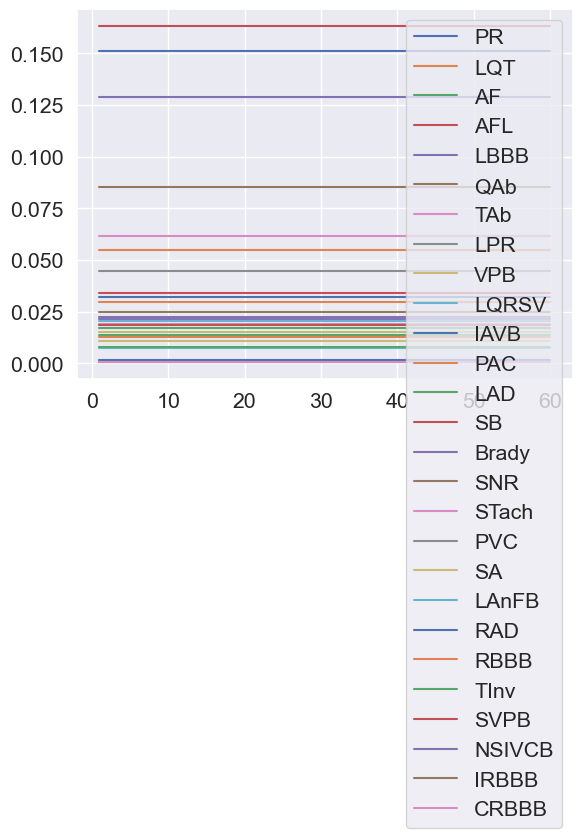

In [133]:
df_avg_scores.plot()

In [134]:
import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------
# 0) Inputs already have
# ---------------------------
# ecg_filenames : list/array of all file paths
# y             : (N_all, 27) one-hot or multi-hot labels
# folds         : your CV folds; use the same val fold you used to build X
# X             : pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0]
# lead_names    : list of input feature names in model order (len == F), or None if using indices

val_idx = folds[0][1]
X_val   = X                                  # shape (N, T, F) or (N, F) depending on your pipeline
y_val   = y[val_idx]                         # (N, 27)
files_sub = np.asarray(ecg_filenames)[val_idx]
sequence_ids = np.array([Path(str(p)).stem for p in files_sub])   # clean ID, like your 'all_id'

# Decide input feature names (model_features)
if 'lead_names' in globals() and lead_names is not None:
    model_features = list(lead_names)                      # names length must equal F
else:
    # fall back to numeric indices
    F = X_val.shape[2] if X_val.ndim == 3 else X_val.shape[1]
    model_features = list(range(F))

# ---------------------------
# 1) choose a POSITIVE id
# ---------------------------
# Pick a class to be "positive" for (change as needed)
CLASS_NAME = "AF"                                  # e.g., pick AF
TARGET_CLASS = list(snomed_abbr).index(CLASS_NAME) # map to column index in y

pos_mask = (y_val[:, TARGET_CLASS] == 1)
ids_for_test = sequence_ids[pos_mask]
if len(ids_for_test) == 0:
    raise ValueError(f"No positives for class {CLASS_NAME} in this fold.")

positive_sequence_id = np.random.choice(ids_for_test)

# ---------------------------
# 2) build long per-timestep DF (your d_test_normalized equivalent)
# ---------------------------
if X_val.ndim == 3:
    N, T, F = X_val.shape
    assert (len(model_features) == F) if isinstance(model_features[0], (str,)) else True

    # DataFrame with one row per (sequence, timestep)
    df_seq = pd.DataFrame(
        X_val.reshape(N*T, F),
        columns=model_features if isinstance(model_features[0], (str,)) else None
    )
    df_seq["sequence_id"] = np.repeat(sequence_ids, T)
    df_seq["timestep"]    = np.tile(np.arange(T), N)
else:
    # If your X_val is already (N, F) aggregated, treat each row as a single-step sequence
    N, F = X_val.shape
    df_seq = pd.DataFrame(
        X_val,
        columns=model_features if isinstance(model_features[0], (str,)) else None
    )
    df_seq["sequence_id"] = sequence_ids
    df_seq["timestep"]    = 0

# This plays the role of your d_test_normalized
d_test_normalized = df_seq

# ---------------------------
# 3) select model features only for that positive sequence
# ---------------------------
pos_x_pd = d_test_normalized[d_test_normalized["sequence_id"] == positive_sequence_id]

# If you used numeric indices for model_features, select columns by position:
if isinstance(model_features[0], (int, np.integer)):
    # keep only feature columns by index
    feat_cols = [c for i, c in enumerate(pos_x_pd.columns) if i in model_features]
    pos_x_data_2d = pos_x_pd[feat_cols].to_numpy().copy()
else:
    # feature names path
    pos_x_data_2d = pos_x_pd[model_features].to_numpy().copy()

# ---------------------------
# 4) make it (1, T, F) for TimeSHAP
# ---------------------------
pos_x_data = np.expand_dims(pos_x_data_2d, axis=0)   # shape (1, T, F)
print("pos_x_data shape:", pos_x_data.shape)
print("positive_sequence_id:", positive_sequence_id)


pos_x_data shape: (1, 5000, 12)
positive_sequence_id: A2563


In [136]:
%pip uninstall -y shap
%pip install "shap<=0.42.1"

Found existing installation: shap 0.48.0
Uninstalling shap-0.48.0:
  Successfully uninstalled shap-0.48.0
Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\site-packages\pip\_internal\cli\base_command.py", line 160, in exc_logging_wrapper
    status = run_func(*args)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\site-packages\pip\_internal\req\req_uninstall.py", line 424, in commit
    self._moved_paths.commit()
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\site-packages\pip\_internal\req\req_uninstall.py", line 277, in commit
    save_dir.cleanup()
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p

     ---------------------------------------- 0.0/462.3 kB ? eta -:--:--
     ----------------------------- ------- 368.6/462.3 kB 11.6 MB/s eta 0:00:01
     -------------------------------------- 462.3/462.3 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: slicer
    Found existing installation: slicer 0.0.8
    Uninstalling slicer-0.0.8:
      Successfully uninstalled slicer-0.0.8
Note: you may need to restart the kernel to use updated packages.


In [142]:
from timeshap.explainer import local_report

plot_feats = {name: f"Lead {name}" for name in lead_names}

# local report parameters
pruning_dict = {'tol': 0.075}
event_dict = {'rs': 42, 'nsamples': 32000}
feature_dict = {'rs': 42, 'nsamples': 32000, 'feature_names': model_features, 'plot_features': plot_feats}
cell_dict = {'rs': 42, 'nsamples': 32000, 'top_x_feats': 2, 'top_x_events': 2}

In [158]:

from timeshap.explainer import local_report

pruning_dict = {'tol': 0.025}
event_dict = {'rs': 42, 'nsamples': 32000}
feature_dict = {'rs': 42, 'nsamples': 32000, 'feature_names': model_features, 'plot_features': plot_feats}
cell_dict = {'rs': 42, 'nsamples': 32000, 'top_x_feats': 2, 'top_x_events': 2}
local_report(f, pos_x_data, pruning_dict, event_dict, feature_dict, cell_dict=cell_dict, entity_uuid=positive_sequence_id, entity_col='all_id', baseline=average_event)

Assuming all features are model features


AssertionError: model must be of type Model!

### SHAP Analysis

In [71]:
# Load ECG input (already using your utility function)
ecg_file = "data/china-12lead-ecg-challenge-database/Training_2/Q0002.mat"
sample_input = prepare_ecg(ecg_file)

# Background data for SHAP
background = np.vstack([prepare_ecg(f) for f in ecg_filenames[:50]])  # Use 50 or fewer to save memory

# Create the SHAP Gradient Explainer
explainer = shap.GradientExplainer(model, background)

# Get SHAP values for your sample
shap_values = explainer.shap_values(sample_input)

C:\Users\nares\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\backend.py:452: UserWarning:

`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.



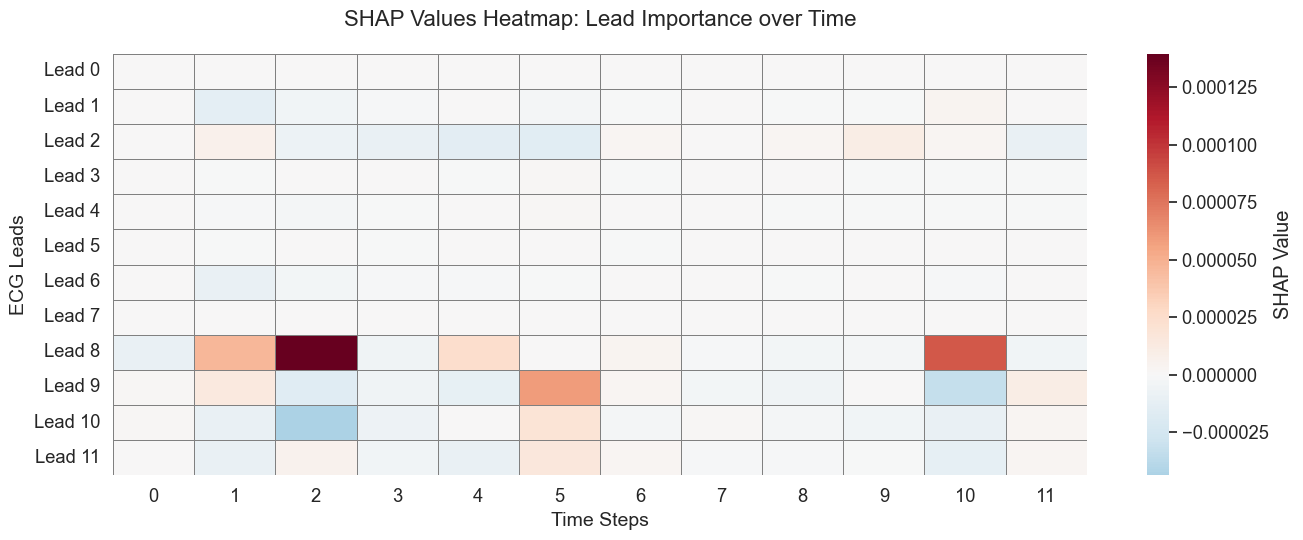

In [72]:
# shap_values[0][0] has shape (5000, 12), but you're showing a slice (e.g., first 12 time steps)
heatmap_data = shap_values[0][0][:, :12].T  # shape (12 leads, 12 time steps)

plt.figure(figsize=(14, 6))
sns.set_theme(font_scale=1.2)
sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'SHAP Value'},
    xticklabels=range(heatmap_data.shape[1]),
    yticklabels=[f"Lead {i}" for i in range(heatmap_data.shape[0])],
    linewidths=0.5,
    linecolor='gray'
)

plt.title("SHAP Values Heatmap: Lead Importance over Time", fontsize=16, pad=20)
plt.xlabel("Time Steps", fontsize=14)
plt.ylabel("ECG Leads", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout(pad=2.0)
plt.show()


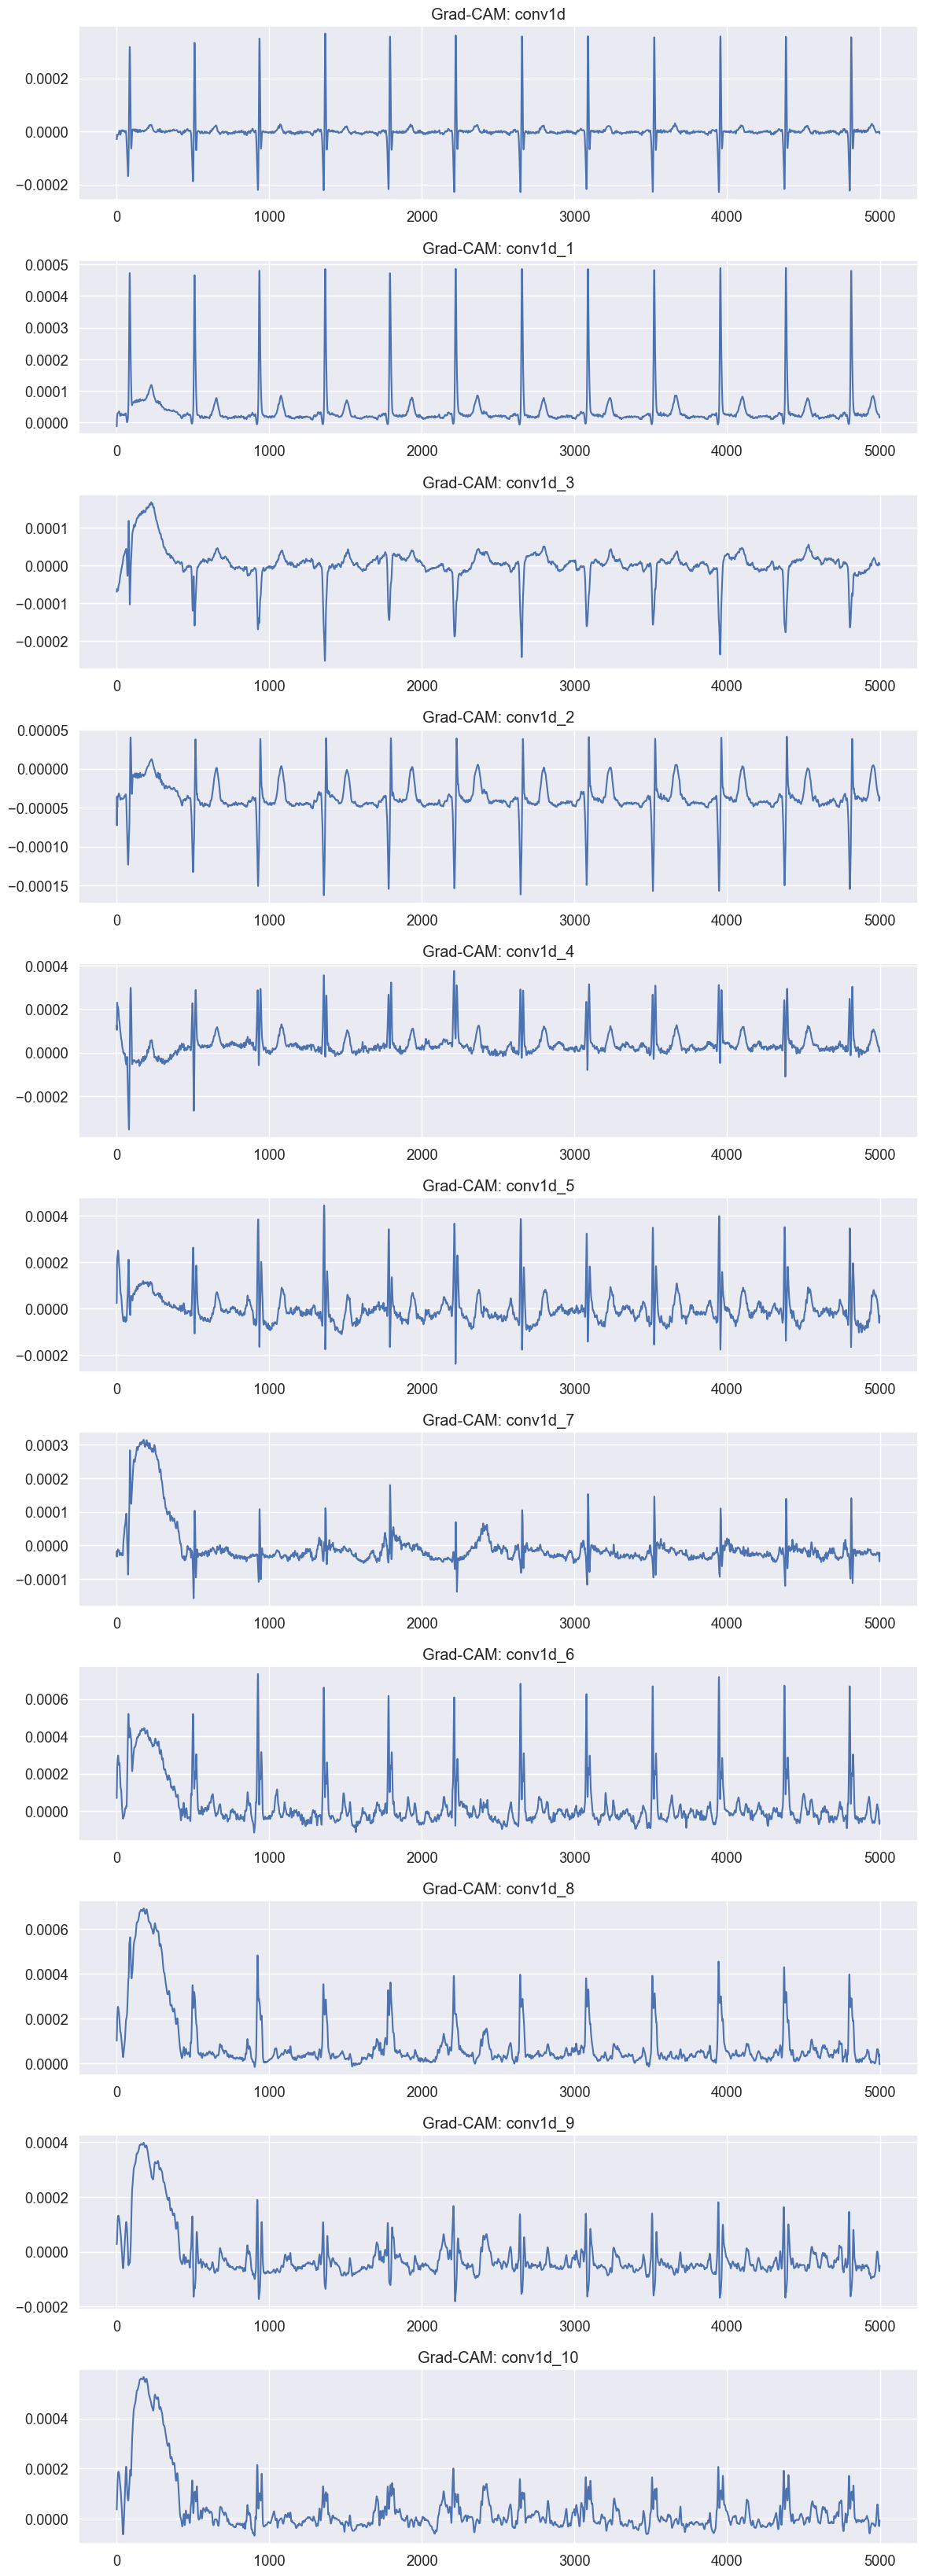

In [73]:
def grad_cam_1d(model, input_data, layer_name):
    """
    Compute Grad-CAM for a specific 1D layer.
    """
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        inputs = tf.cast(input_data, tf.float32)
        conv_outputs, predictions = grad_model(inputs)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    
    # Global average pooling over time dimension
    weights = tf.reduce_mean(grads, axis=1)
    
    # Weighted sum
    cam = tf.reduce_sum(tf.multiply(weights[:, tf.newaxis, :], conv_outputs), axis=-1)
    return cam.numpy()


def grad_cam_all_layers(model, input_data, layer_types=(tf.keras.layers.Conv1D,)):
    """
    Compute Grad-CAM for all layers of given types (default: Conv1D).
    Returns a dict of {layer_name: cam_output}.
    """
    cams = {}
    
    for layer in model.layers:
        if isinstance(layer, layer_types):
            try:
                cam = grad_cam_1d(model, input_data, layer.name)
                cams[layer.name] = cam
            except Exception as e:
                print(f"Skipping {layer.name} due to error: {e}")
    
    return cams


def plot_grad_cams(cams, sample_idx=0):
    """
    Plot Grad-CAM heatmaps for a given sample across all layers.
    """
    n_layers = len(cams)
    plt.figure(figsize=(12, 3 * n_layers))
    
    for i, (layer_name, cam) in enumerate(cams.items(), 1):
        plt.subplot(n_layers, 1, i)
        plt.plot(cam[sample_idx])
        plt.title(f"Grad-CAM: {layer_name}")
    
    plt.tight_layout()
    plt.show()


# Usage example
sample_input = prepare_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0002.mat")
cams = grad_cam_all_layers(model, sample_input)

plot_grad_cams(cams, sample_idx=0)



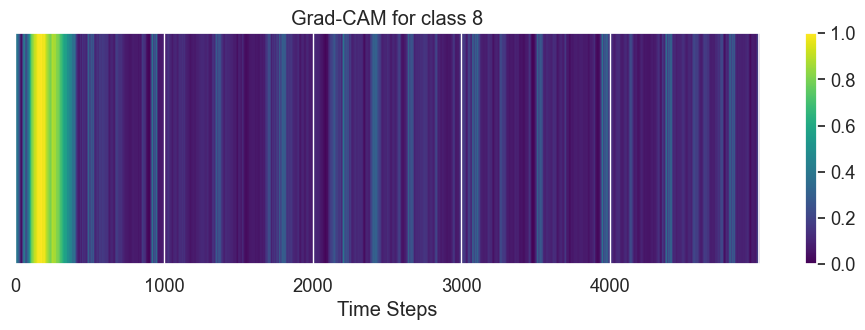

In [74]:
# build model to output last conv layer + predictions
# find last Conv1D layer
conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv1D)]
if not conv_layers:
    raise ValueError("No Conv1D layers found in model.")

last_conv = conv_layers[-1]

grad_model = tf.keras.Model([model.inputs], [last_conv.output, model.output])

# forward + backward pass
with tf.GradientTape() as tape:
    conv_out, preds = grad_model(sample_input)
    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

# compute gradients wrt conv features
grads = tape.gradient(loss, conv_out)
weights = tf.reduce_mean(grads, axis=1)   # average over time axis
cam = tf.reduce_sum(tf.multiply(weights, conv_out), axis=-1)

# normalize CAM
cam = cam[0].numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())

# plot heatmap
plt.figure(figsize=(12, 3))
plt.imshow(cam[np.newaxis, :], aspect="auto", cmap="viridis")
plt.title(f"Grad-CAM for class {class_idx.numpy()}")
plt.xlabel("Time Steps")
plt.yticks([])
plt.colorbar()
plt.show()


In [75]:
x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0]

In [76]:
print(x.shape)

(4311, 5000, 12)


In [77]:
# 1) Find ECG batch from common names (X_test, X_val, signals, etc.)
ecg_raw, ecg_varname = find_ecg_batch(globals())
ecg_batch = to_batch_L_T(x)        # (B, L, T)
fs = 500     # or set fs = 500

# 2) Choose a sample
idx = 0
ecg_single = ecg_batch[idx]              # (L, T)

# 3) Wrap your Keras model
predict_fn = make_keras_predict_fn(model, expects_time_lead=True)

# 4) Attribution
# If you don't already have attributions, compute IG as a fallback:
probs = predict_fn(ecg_single[None, ...])
class_index = int(np.argmax(probs[0]))
attr_single = integrated_gradients_keras(model, ecg_single, target_index=class_index)  # (L, T)

## Clinically-aligned attribution: per-lead, per-wave

In [78]:
lead_wave = lead_wave_table(attr_single, ecg_single, fs)
lead_wave

{'lead_1': {'P': 0.21090971203894954,
  'QRS': 0.32495139410311275,
  'ST': 0.08748192608797734,
  'T': 0.37665683441201153},
 'lead_2': {'P': 0.22928809583325088,
  'QRS': 0.2970983019806268,
  'ST': 0.10354172040134217,
  'T': 0.37007163405195526},
 'lead_3': {'P': 0.22957060694644138,
  'QRS': 0.31562255174518017,
  'ST': 0.1055109212866199,
  'T': 0.3492958245174797},
 'lead_4': {'P': 0.25113943061889593,
  'QRS': 0.28833550130940944,
  'ST': 0.09753235987165712,
  'T': 0.3629924949332501},
 'lead_5': {'P': 0.25580984299529075,
  'QRS': 0.28693647036162934,
  'ST': 0.10298755500826177,
  'T': 0.35426592916125593},
 'lead_6': {'P': 0.2833360046406165,
  'QRS': 0.23839695664753702,
  'ST': 0.09846230495284253,
  'T': 0.3798046117903181},
 'lead_7': {'P': 0.2794397399600213,
  'QRS': 0.24635730892616356,
  'ST': 0.09759812821977351,
  'T': 0.3766046829732154},
 'lead_8': {'P': 0.27814920670060883,
  'QRS': 0.25205853374877824,
  'ST': 0.1020420118148652,
  'T': 0.36775009452237234},
 

## Faithfulness curves (Insertion/Deletion AUC)

Insertion AUC: 0.02420815200544894
Deletion AUC: 0.019123974135145546


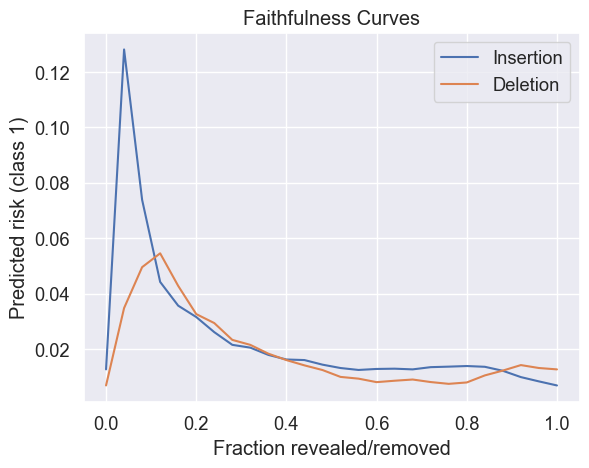

In [79]:
fra, scr, auc_ins = insertion_deletion_auc(predict_fn, ecg_single, attr_single, class_index=1, steps=25, mode='insertion', baseline=0.0)
fra2, scr2, auc_del = insertion_deletion_auc(predict_fn, ecg_single, attr_single, class_index=1, steps=25, mode='deletion', baseline=0.0)

print('Insertion AUC:', auc_ins)
print('Deletion AUC:', auc_del)

plt.figure()
plt.plot(fra, scr, label='Insertion')
plt.plot(fra2, scr2, label='Deletion')
plt.xlabel('Fraction revealed/removed')
plt.ylabel('Predicted risk (class 1)')
plt.legend()
plt.title('Faithfulness Curves')
plt.show()

## Simple overlay plot

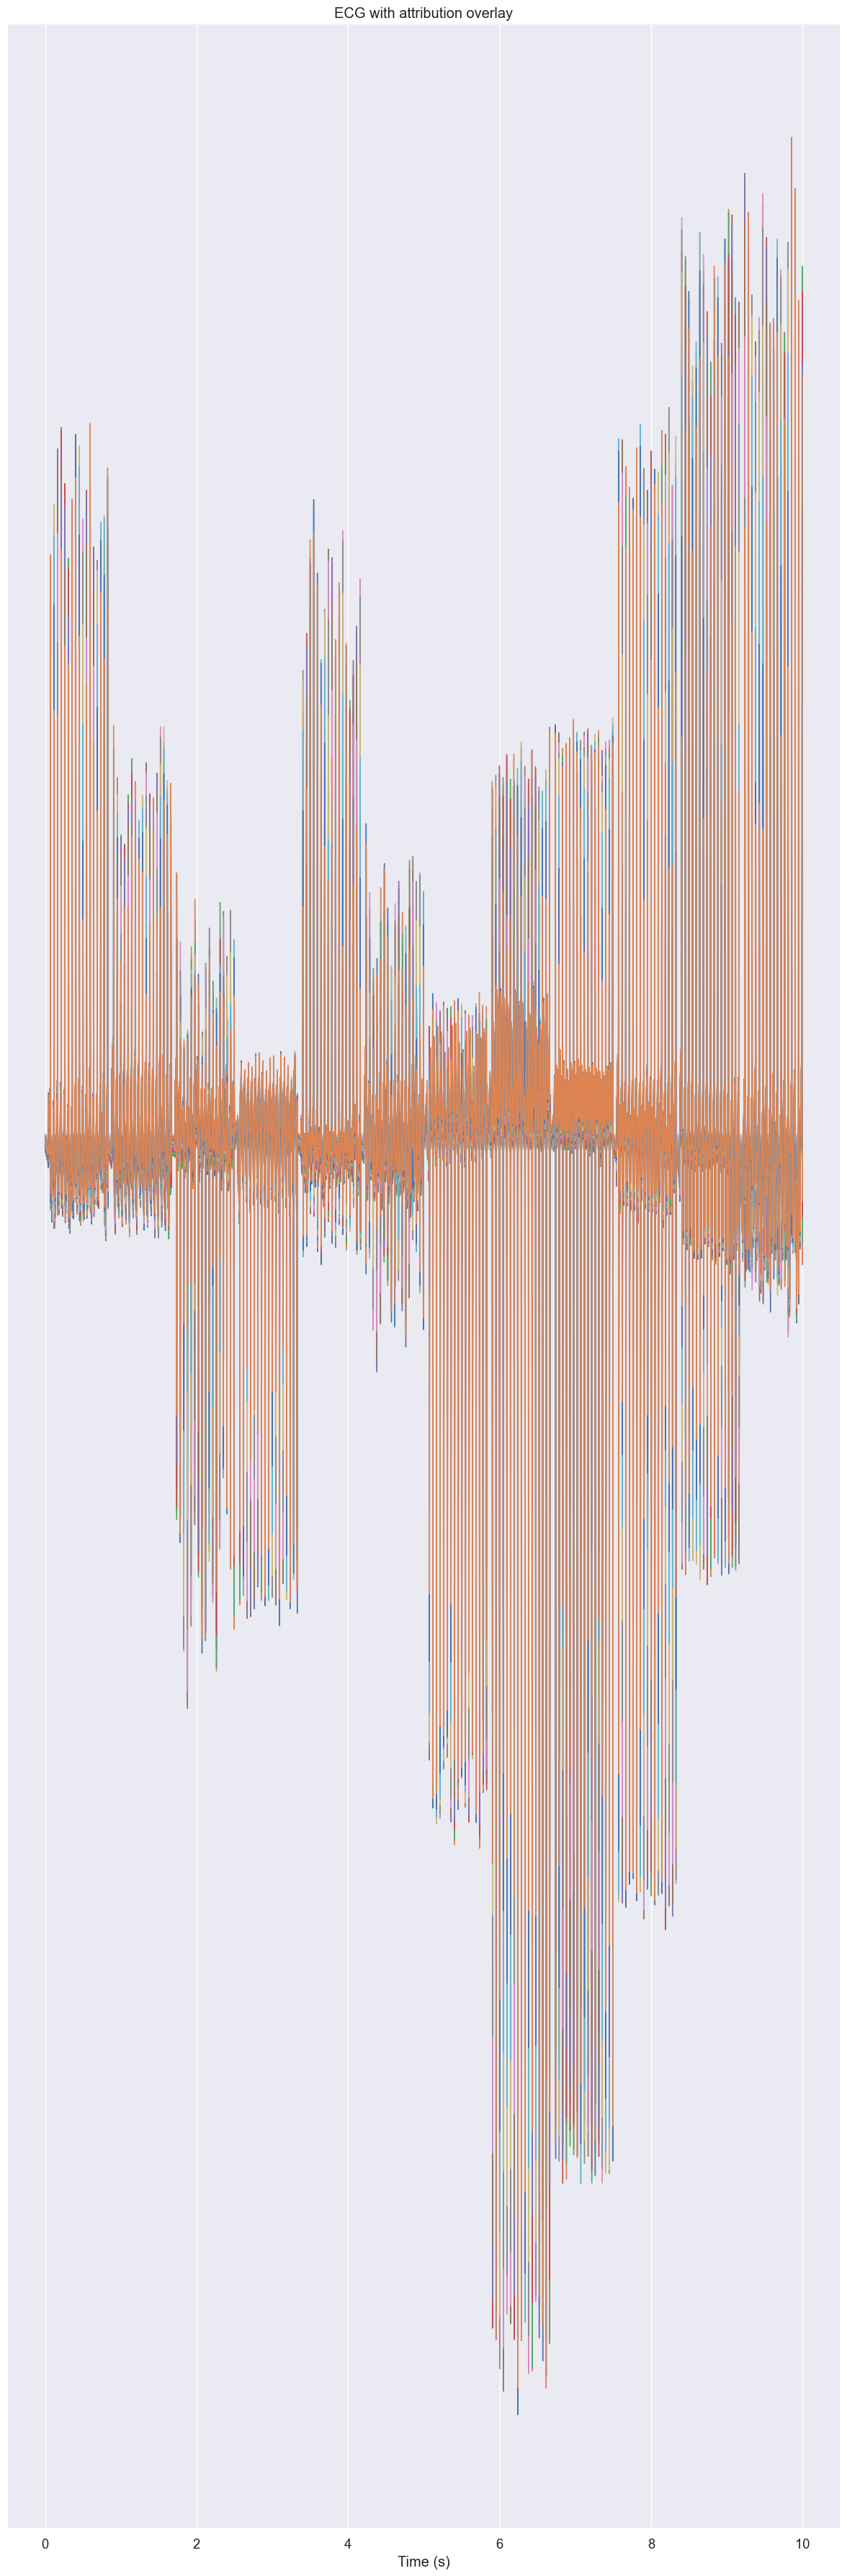

In [80]:
t = np.arange(ecg_single.shape[1]) / fs
plt.figure(figsize=(12, 3*ecg_single.shape[0]))

for li in range(ecg_single.shape[0]):
    offset = 2.5 * li
    plt.plot(t, ecg_single[li] + offset, linewidth=1.0)
    a = np.abs(attr_single[li])
    a = a / (a.max() + 1e-8)
    plt.fill_between(t, offset, ecg_single[li] + offset, alpha=0.25, where=a>0, interpolate=True)

plt.xlabel('Time (s)')
plt.yticks([])
plt.title('ECG with attribution overlay')
plt.tight_layout()
plt.show()


---

# 🔍 Explainability Add-on (SHAP + LIME Overlays)
This section appends per-timestep ECG overlays showing which parts of the signal push the prediction toward the **target class** (red) or away (blue).
If you already have `model`, `X` (shape `(N, T, L)` or `(N, T)`), and `CLASS_NAMES` defined above, this will use them automatically.
    

In [81]:
X = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0]

In [90]:
# --- Use your 27 SNOMED abbreviations as CLASS_NAMES ---
# Assumes `snomed_abbr` is a 1-D array or list like:
# ['PR','LQT','AF','AFL','LBBB','QAb','TAb','LPR','VPB','LQRSV','IAVB','PAC',
#  'LAD','SB','Brady','SNR','STach','PVC','SA','LAnFB','RAD','RBBB','TInv',
#  'SVPB','NSIVCB','IRBBB','CRBBB']
CLASS_NAMES = list(snomed_abbr)

# Optional: choose a subset to run (e.g., just AF and RBBB). Leave as None to run all.
TARGET_CLASS_NAMES = None  # e.g., ['AF', 'RBBB']
SAVE_PLOTS = False         # True = save PNGs instead of showing (helps avoid 27×L popups)
OUTPUT_DIR = "shap_overlays"
RANDOM_SEED = 42  # for reproducibility

# --- existing checks/normalization from your code (unchanged) ---
_have_model = 'model' in globals()
_have_X = 'X' in globals()
_have_classes = 'CLASS_NAMES' in globals()

if not _have_model or not _have_X:
    print("Note: Could not find `model` and/or `X` in this notebook's globals.")
    print("      Please ensure your trained Keras model is in `model` and your data in `X` (N,T,L).")
    raise SystemExit

if X.ndim == 2:
    X = X[..., None]
N, T, L = X.shape

# Sample pick (keep your existing SAMPLE_INDEX or default to 0)
SAMPLE_INDEX = globals().get('SAMPLE_INDEX', 0)
idx = int(SAMPLE_INDEX) % N
x_sample = X[idx:idx+1]  # (1,T,L)

# --- helper funcs from your code (unchanged) ---
def plot_ecg_overlay(time, signal, contrib, title="ECG with Overlay", lead_name=None, vmin=None, vmax=None):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.collections import LineCollection
    from matplotlib.colors import TwoSlopeNorm

    signal = np.asarray(signal).reshape(-1)
    contrib = np.asarray(contrib).reshape(-1)
    Tloc = len(signal)
    if time is None:
        time = np.arange(Tloc)
    if vmin is None or vmax is None:
        amax = np.nanmax(np.abs(contrib)) if np.nanmax(np.abs(contrib))>0 else 1.0
        vmin, vmax = -amax, amax

    points = np.array([time, signal]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = TwoSlopeNorm(vcenter=0.0, vmin=vmin, vmax=vmax)
    lc = LineCollection(segments, cmap='coolwarm', norm=norm)
    lc.set_array(contrib[:-1])
    lc.set_linewidth(1.5)

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.add_collection(lc)
    ax.set_xlim(time.min(), time.max())
    pad = 0.05*(signal.max()-signal.min() + 1e-8)
    ax.set_ylim(signal.min()-pad, signal.max()+pad)
    ax.set_title(title + (f" — Lead: {lead_name}" if lead_name else "")) 
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("mV")
    cbar = plt.colorbar(lc, ax=ax)
    cbar.set_label("Contribution → target class (red = positive, blue = negative)")
    return fig, ax  # return the fig so we can save it if needed

def summarize_top_segments(contrib, segment_len=40, top_k=10, min_gap=20):
    import numpy as np
    Tloc = len(contrib)
    scores = np.array([contrib[i:i+segment_len].sum() for i in range(0, max(1, Tloc-segment_len+1))])
    idxs = scores.argsort()[::-1]
    selected = []
    for i in idxs:
        s, e = i, i+segment_len
        if all((abs(s - ps) >= min_gap and abs(e - pe) >= min_gap) for ps, pe, _ in selected):
            selected.append((s, e, scores[i]))
            if len(selected) >= top_k:
                break
    return selected

# --- determine num_classes (your existing logic) ---
try:
    if isinstance(CLASS_NAMES, (list, tuple)):
        num_classes = len(CLASS_NAMES)
    else:
        num_classes = None
except NameError:
    num_classes = None
    CLASS_NAMES = None

try:
    if num_classes is None:
        out_shape = getattr(model, 'output_shape', None)
        if isinstance(out_shape, list):
            out_shape = out_shape[0]
        num_classes = out_shape[-1] if out_shape is not None and isinstance(out_shape[-1], int) else None
except Exception:
    pass

# --- converter (unchanged) ---
def to_class_T_L(shap_values, X, num_classes_hint=None):
    import numpy as np
    T, L = X.shape[1], X.shape[2]

    if isinstance(shap_values, list):
        arrs = []
        for sv in shap_values:
            sv = np.asarray(sv)
            if sv.ndim == 3:      # (n_samples, T, L)
                arrs.append(sv[0])
            elif sv.ndim == 2:    # (T, L)
                arrs.append(sv)
            elif sv.ndim == 1 and sv.size == T*L:
                arrs.append(sv.reshape(T, L))
            else:
                raise ValueError(f"Unexpected per-class sv shape {sv.shape}")
        return np.stack(arrs, axis=0)  # (num_classes, T, L)

    sv = np.asarray(shap_values)

    if sv.ndim == 4 and sv.shape[0] == 1 and (num_classes_hint is None or sv.shape[-1] == num_classes_hint):
        return np.moveaxis(sv[0], -1, 0)  # -> (C, T, L)

    if sv.ndim == 4 and sv.shape[0] == 1 and (num_classes_hint is None or sv.shape[1] == num_classes_hint):
        return sv[0]  # already (C, T, L)

    if sv.ndim == 3 and sv.shape[0] == 1:
        return sv.reshape(1, T, L)  # (1, T, L)

    if sv.ndim == 2 and sv.shape[0] == 1 and sv.shape[1] == T*L:
        return sv.reshape(1, T, L)
    if sv.ndim == 1 and sv.size == T*L:
        return sv.reshape(1, T, L)

    raise ValueError(f"Don't know how to convert SHAP array with shape {sv.shape} to (classes, T, L).")

# --- Harmonize once ---
shap_arr = to_class_T_L(shap_values, X, num_classes_hint=num_classes)  # (C, T, L)
print("shap_values shape:", np.asarray(shap_values).shape)
print("harmonized shap_arr:", shap_arr.shape)

# --- Decide which classes to run ---
if TARGET_CLASS_NAMES is None:
    TARGET_CLASS_NAMES = CLASS_NAMES if CLASS_NAMES is not None else list(range(shap_arr.shape[0]))

# Prepare saving, if desired
if SAVE_PLOTS:
    import os
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Loop over classes ---
import numpy as np
import matplotlib.pyplot as plt

time_axis = np.arange(T)

shap_values shape: (1, 5000, 12, 27)
harmonized shap_arr: (27, 5000, 12)


In [96]:
# --- Interactive viewer: pick class, lead, and sample on demand ---
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display, clear_output  # <- add this

CLASS_NAMES = list(snomed_abbr)

# controls
N, T, L = X.shape
class_opts = [(name, i) for i, name in enumerate(CLASS_NAMES)]
lead_slider = IntSlider(description='Lead', min=1, max=L, step=1, value=1)
sample_slider = IntSlider(description='Sample', min=0, max=N-1, step=1, value=int(globals().get('SAMPLE_INDEX', 0)))

@interact(
    cls=Dropdown(options=class_opts, description='Class'),
    lead=lead_slider,
    idx=sample_slider
)
def show_overlay(cls, lead, idx):
    clear_output(wait=True)  # <- prevents stacking/duplicates
    x_sample = X[idx:idx+1]
    sv = to_class_T_L(shap_values, X, num_classes_hint=len(CLASS_NAMES))
    contrib = sv[cls]  # (T, L)

    time_axis = np.arange(T)
    fig, ax = plot_ecg_overlay(
        time=time_axis,
        signal=x_sample[0, :, lead-1],
        contrib=contrib[:, lead-1],
        title=f"SHAP overlay — class '{CLASS_NAMES[cls]}'",
        lead_name=f"Lead {lead}"
    )
    display(fig)     # <- explicitly display once
    plt.close(fig)   # <- and close so it won't auto-display again


interactive(children=(Dropdown(description='Class', options=(('PR', 0), ('LQT', 1), ('AF', 2), ('AFL', 3), ('L…

In [93]:
from lime.lime_tabular import LimeTabularExplainer
from sklearn.utils import check_random_state
import numpy as np

def segment_time_series(x, n_segments=50):
    Tloc = x.shape[0]
    bounds = np.linspace(0, Tloc, n_segments+1).astype(int)
    return [(bounds[i], bounds[i+1]) for i in range(n_segments)]

def lime_explain_timeseries_leadaware(model, x, class_idx, n_segments=40, num_samples=2000, seed=0):
    """
    x: (T, L) single sample
    Returns: contrib_map (T, L), segments, exp
    """
    Tloc, Lloc = x.shape
    segments = segment_time_series(x[:, 0], n_segments=n_segments)
    rng = check_random_state(seed)

    # Features are (segment, lead) -> total n_feat = n_segments * L
    n_feat = len(segments) * Lloc

    # Build background "binary mask" samples
    training_data = rng.randint(0, 2, size=(min(4096, max(1024, n_feat*6)), n_feat))
    feat_names = [f"{s}-{e}@L{ell+1}" for (s,e) in segments for ell in range(Lloc)]

In [94]:
# --- Interactive LIME viewer: pick class, lead, and sample on demand ---
# Requirements: ipywidgets, matplotlib
# Assumes you already defined:
# - model (Keras), X with shape (N,T,L), CLASS_NAMES
# - segment_time_series, lime_explain_timeseries_leadaware
# - plot_ecg_overlay (from your SHAP code)

import numpy as np
import matplotlib.pyplot as plt

# Optional: nicer widget UX, but will still work without this import.
try:
    from ipywidgets import interact, interactive_output, VBox, HBox, Dropdown, IntSlider, Button, Layout
except Exception as e:
    print("ipywidgets not available. Install with `pip install ipywidgets` and enable in Jupyter if needed.")
    raise

# --- Basic sanity/shape normalization ---
_have_model = 'model' in globals()
_have_X = 'X' in globals()
_have_classes = 'CLASS_NAMES' in globals()

if not _have_model or not _have_X:
    print("Note: Could not find `model` and/or `X` in this notebook's globals.")
    print("      Please ensure your trained Keras model is in `model` and your data in `X` (N,T,L).")
    raise SystemExit

if X.ndim == 2:
    X = X[..., None]
N, T, L = X.shape

if not _have_classes or not isinstance(CLASS_NAMES, (list, tuple)) or len(CLASS_NAMES) == 0:
    CLASS_NAMES = [f"class_{i}" for i in range(getattr(model, 'output_shape', [None, None, 1])[-1])]

# --- Lightweight cache to avoid recomputing LIME every time you wiggle a slider ---
# Key: (sample_idx, class_idx, n_segments, num_samples, seed)
_lime_cache = {}

def get_lime_map_cached(sample_idx, class_idx, n_segments, num_samples, seed):
    key = (int(sample_idx), int(class_idx), int(n_segments), int(num_samples), int(seed))
    if key in _lime_cache:
        return _lime_cache[key]
    x_sample = X[sample_idx]  # (T, L)
    contrib_map, segments, exp = lime_explain_timeseries_leadaware(
        model, x_sample, class_idx=class_idx,
        n_segments=int(n_segments),
        num_samples=int(num_samples),
        seed=int(seed)
    )
    _lime_cache[key] = (contrib_map, segments, exp)
    return _lime_cache[key]

# --- Controls ---
default_sample = int(globals().get('SAMPLE_INDEX', 0)) % N
default_class_idx = 0

w_class = Dropdown(options=[(name, i) for i, name in enumerate(CLASS_NAMES)],
                   value=default_class_idx, description='Class:', layout=Layout(width='300px'))

w_lead  = IntSlider(description='Lead', min=1, max=L, step=1, value=1, layout=Layout(width='300px'))
w_idx   = IntSlider(description='Sample', min=0, max=N-1, step=1, value=default_sample, layout=Layout(width='400px'))

# LIME knobs (keep sensible limits so interaction stays snappy)
w_segments    = IntSlider(description='Segments', min=10, max=120, step=5, value=40, layout=Layout(width='350px'))
w_num_samples = IntSlider(description='Num samples', min=200, max=5000, step=200, value=2000, layout=Layout(width='350px'))
w_seed        = IntSlider(description='Seed', min=0, max=10, step=1, value=int(globals().get('RANDOM_SEED', 0)),
                          layout=Layout(width='200px'))

# Clear cache button (useful after model/data changes)
btn_clear_cache = Button(description='Clear LIME cache', layout=Layout(width='200px'))
def _clear_cache(_):
    _lime_cache.clear()
    print("LIME cache cleared.")
btn_clear_cache.on_click(_clear_cache)

# --- Plotting callback ---
def _render(class_idx, lead, idx, segments, num_samples, seed):
    # Compute LIME contributions (T, L) for this sample & class
    lime_map, lime_segments, lime_exp = get_lime_map_cached(idx, class_idx, segments, num_samples, seed)
    x_sample = X[idx]  # (T, L)
    lead_idx = int(lead) - 1

    # Plot a single overlay (Option 1 behavior)
    plt.close('all')
    fig, ax = plot_ecg_overlay(
        time=np.arange(T),
        signal=x_sample[:, lead_idx],
        contrib=lime_map[:, lead_idx],
        title=f"LIME lead-aware overlay — '{CLASS_NAMES[class_idx]}'",
        lead_name=f"Lead {lead}"
    )
    plt.show()

    # Small textual summary to guide exploration
    per_lead_strength = np.abs(lime_map).mean(axis=0)
    top_leads = np.argsort(per_lead_strength)[::-1][:min(5, L)]
    print("Top leads by mean |LIME|:", [int(i+1) for i in top_leads])
    # Segment quicklook (mean across leads)
    seg_scores = []
    for (s, e) in lime_segments:
        seg_scores.append((s, e, float(lime_map[s:e].mean())))
    seg_scores = sorted(seg_scores, key=lambda t: abs(t[2]), reverse=True)[:8]
    print("Top segments (by mean contrib across leads):")
    for s, e, sc in seg_scores:
        print(f"  {s:5d}–{e:5d}  score={sc:+.4f}")

# Wire up the interactive output
out = interactive_output(
    _render,
    {
        'class_idx': w_class,
        'lead': w_lead,
        'idx': w_idx,
        'segments': w_segments,
        'num_samples': w_num_samples,
        'seed': w_seed
    }
)

# Display the UI
ui_top = HBox([w_class, w_lead, w_idx])
ui_bottom = HBox([w_segments, w_num_samples, w_seed, btn_clear_cache])
display(VBox([ui_top, ui_bottom, out]))


In [97]:
from typing import Optional, Sequence, Callable, List, Tuple
import numpy as np

def describe_findings_clear(
    shap_contrib: np.ndarray,
    lime_contrib: np.ndarray,
    top_k: int = 10,
    target_name: Optional[str] = None,
    lead_names: Optional[Sequence[str]] = None,
    segment_len: Optional[int] = None,
    signal_len: Optional[int] = None,
    summarize_fn: Optional[Callable[[np.ndarray, int, int], List[Tuple[int, int, float]]]] = None,
    show_negative: bool = False,
) -> str:
    """
    Clear, clinician-friendly summary:
      • SHAP → which leads contributed to the target class (direction +/−).
      • LIME → when (time intervals) the signal mattered most.
      • Combined → intervals with agreement between SHAP (mean over leads) and LIME.

    Parameters are the same as your original, plus:
      show_negative: if True, also list the strongest negative (counter-evidence) SHAP leads.
    """
    # ---- Checks & setup ----
    if shap_contrib.ndim != 2:
        raise ValueError("shap_contrib must be 2D with shape (T, L).")
    if lime_contrib.ndim != 1:
        raise ValueError("lime_contrib must be 1D with shape (T,).")

    T, L = shap_contrib.shape
    if lime_contrib.shape[0] != T:
        raise ValueError(f"Shape mismatch: shap_contrib has T={T} but lime_contrib has {lime_contrib.shape[0]}.")
    if lead_names is not None and len(lead_names) != L:
        raise ValueError(f"lead_names length {len(lead_names)} must match number of leads {L}.")

    label_target = target_name or "Target"
    names = list(lead_names) if lead_names is not None else [f"Lead {i+1}" for i in range(L)]

    if signal_len is None:
        signal_len = T
    if segment_len is None:
        segment_len = max(20, signal_len // 50)

    # segment extractor
    if summarize_fn is None:
        try:
            summarize_fn = summarize_top_segments  # provided elsewhere in your notebook
        except NameError as e:
            raise ValueError("summarize_fn was not provided and summarize_top_segments is not defined.") from e

    # ---------- SHAP: which leads? ----------
    # Positive and negative evidence per lead
    pos_by_lead = np.clip(shap_contrib, 0, None).sum(axis=0)  # toward class
    neg_by_lead = np.clip(shap_contrib, None, 0).sum(axis=0)  # against class (negative sums)

    # Rank leads by positive evidence
    kL = min(top_k, L)
    pos_order = np.argsort(pos_by_lead)[::-1][:kL]
    total_pos = float(pos_by_lead.sum()) if pos_by_lead.sum() != 0 else 1.0

    def pct_pos(v: float) -> float:
        return (100.0 * v / total_pos) if total_pos > 0 else 0.0

    shap_lead_lines = [
        f"• {names[i]} — positive SHAP Σ={pos_by_lead[i]:.3f} ({pct_pos(pos_by_lead[i]):.1f}%)"
        for i in pos_order if pos_by_lead[i] > 0
    ]
    if show_negative:
        # Show strongest counter-evidence leads (most negative sums)
        neg_order = np.argsort(neg_by_lead)[:kL]  # more negative first
        shap_neg_lines = [
            f"• {names[i]} — negative SHAP Σ={neg_by_lead[i]:.3f}"
            for i in neg_order if neg_by_lead[i] < 0
        ]
    else:
        shap_neg_lines = []

    # ---------- LIME: when (time intervals)? ----------
    # Rank intervals by LIME alone
    lime_segments = summarize_fn(lime_contrib, segment_len=segment_len, top_k=top_k)
    lime_segment_lines = [
        f"{r}. {s}–{e} (len={e-s}) | LIME score={sc:.2f}"
        for r, (s, e, sc) in enumerate(lime_segments, 1)
    ]

    # ---------- Combined: agreement across time ----------
    shap_mean_time = shap_contrib.mean(axis=1)  # (T,)
    combined = shap_mean_time + lime_contrib
    comb_segments = summarize_fn(combined, segment_len=segment_len, top_k=top_k)
    comb_segment_lines = [
        f"{r}. {s}–{e} (len={e-s}) | (SHAP + LIME)={sc:.2f}"
        for r, (s, e, sc) in enumerate(comb_segments, 1)
    ]

    # Also show which leads are active in top combined window (quick context)
    context_line = ""
    if comb_segments:
        s0, e0, _ = comb_segments[0]
        # mean |SHAP| by lead in that window
        win_strength = np.abs(shap_contrib[s0:e0, :]).mean(axis=0)
        top_leads_in_win = np.argsort(win_strength)[::-1][:min(5, L)]
        context_line = "In the top combined interval, strongest leads: " + ", ".join(
            f"{names[i]} (|SHAP|̄={win_strength[i]:.3f})" for i in top_leads_in_win
        )

    # ---------- Assemble message ----------
    lines = []
    lines.append(f"Target: {label_target}")
    lines.append("")
    lines.append("A) Lead importance (SHAP):")
    if shap_lead_lines:
        lines.extend(shap_lead_lines)
    else:
        lines.append("• No positive SHAP evidence found across leads.")
    if shap_neg_lines:
        lines.append("   Counter-evidence (negative SHAP):")
        lines.extend(shap_neg_lines)

    lines.append("")
    lines.append("B) Key time intervals (LIME):")
    if lime_segment_lines:
        lines.extend(lime_segment_lines)
    else:
        lines.append("No salient intervals detected by LIME.")

    lines.append("")
    lines.append("C) Overlap (SHAP mean over leads + LIME):")
    if comb_segment_lines:
        lines.extend(comb_segment_lines)
        if context_line:
            lines.append(context_line)
    else:
        lines.append("No intervals where SHAP and LIME jointly peak.")

    return "\n".join(lines)


In [99]:
def lime_explain_timeseries_leadaware(model, x, class_idx, n_segments=40, num_samples=2000, seed=0):
    """
    x: (T, L) single sample
    Returns: contrib_map (T, L), segments, exp
    """
    Tloc, Lloc = x.shape
    segments = segment_time_series(x[:, 0], n_segments=n_segments)
    rng = check_random_state(seed)

    # Features are (segment, lead) -> total n_feat = n_segments * L
    n_feat = len(segments) * Lloc

    # Build background "binary mask" samples
    training_data = rng.randint(0, 2, size=(min(4096, max(1024, n_feat*6)), n_feat))
    feat_names = [f"{s}-{e}@L{ell+1}" for (s,e) in segments for ell in range(Lloc)]

    # Masking function that zeroes only the selected (segment, lead) features
    def data_generator(mask_vectors):
        M = mask_vectors.shape[0]
        X_masked = np.repeat(x[None, ...], M, axis=0)  # (M, T, L)
        for m in range(M):
            # iterate all features
            fidx = 0
            for j, (s, e) in enumerate(segments):
                for ell in range(Lloc):
                    if mask_vectors[m, fidx] == 0:
                        X_masked[m, s:e, ell] = 0.0
                    fidx += 1
        return model.predict(X_masked, verbose=0)  # (M, C)

    explainer = LimeTabularExplainer(
        training_data,
        feature_names=feat_names,
        class_names=CLASS_NAMES if 'CLASS_NAMES' in globals() else None,
        discretize_continuous=False,
        random_state=rng
    )

    def predict_fn(z):
        return data_generator(z.astype(int))

    # Explain the "all-on" vector
    z0 = np.ones((1, n_feat))
    exp = explainer.explain_instance(
        z0[0],
        predict_fn,
        labels=[class_idx],
        num_features=n_feat,
        num_samples=num_samples
    )

    weights = dict(exp.as_list(label=class_idx))
    contrib_map = np.zeros((Tloc, Lloc), dtype=float)

    # Distribute feature weights uniformly across their covered time span
    fidx = 0
    for j, (s, e) in enumerate(segments):
        for ell in range(Lloc):
            key = feat_names[fidx]
            w = weights.get(key, 0.0)
            if e > s:
                contrib_map[s:e, ell] += w / (e - s)
            fidx += 1

    return contrib_map, segments, exp

In [ ]:
# --- Summaries for ALL classes in CLASS_NAMES for one sample ---

# Assumes you already have:
# - model, X shaped (N,T,L)
# - CLASS_NAMES: list of class names
# - to_class_T_L(...) -> shap_arr shaped (C,T,L)
# - lime_explain_timeseries_leadaware(...)
# - describe_findings_clear(...)  (or use your describe_findings)
# - summarize_top_segments(...)   (if describe_findings_clear relies on it)

import numpy as np

# pick sample
SAMPLE_INDEX = int(globals().get('SAMPLE_INDEX', 0))
if X.ndim == 2:
    X = X[..., None]
N, T, L = X.shape
idx = SAMPLE_INDEX % N
x_sample = X[idx]  # (T, L)

# harmonize SHAP to (C,T,L)
shap_arr = to_class_T_L(shap_values, X, num_classes_hint=len(CLASS_NAMES))  # (C,T,L)

# LIME config (tweak if needed)
N_SEGMENTS = 40
NUM_SAMPLES = 2000
SEED = int(globals().get('RANDOM_SEED', 0))

# Optional: restrict which classes to summarize; set to None for all
TARGET_CLASS_NAMES = None  # e.g., ['AF','RBBB'] or None for all

if TARGET_CLASS_NAMES is None:
    class_indices = list(range(len(CLASS_NAMES)))
else:
    class_indices = [CLASS_NAMES.index(n) for n in TARGET_CLASS_NAMES if n in CLASS_NAMES]

# Pretty separator
def _sep(title: str):
    bar = "=" * max(20, len(title))
    print(f"\n{bar}\n{title}\n{bar}")

# Generate summaries
all_summaries = []  # collect if you want to save later

for cidx in class_indices:
    target_name = CLASS_NAMES[cidx]
    target_contrib = shap_arr[cidx]  # (T, L)

    # LIME (lead-aware) for THIS class & sample
    lime_map, lime_segments, lime_exp = lime_explain_timeseries_leadaware(
        model=model,
        x=x_sample,
        class_idx=cidx,
        n_segments=N_SEGMENTS,
        num_samples=NUM_SAMPLES,
        seed=SEED,
    )
    lime_contrib = lime_map.mean(axis=1)  # (T,)

    # Build the textual summary (use your preferred function)
    summary_text = describe_findings_clear(
        shap_contrib=target_contrib,     # (T, L)
        lime_contrib=lime_contrib,       # (T,)
        top_k=10,
        target_name=target_name,
        lead_names=[f"Lead {i+1}" for i in range(target_contrib.shape[1])],
        # summarize_fn=summarize_top_segments,  # optional; auto-used if available
    )

    # Print nicely
    _sep(f"Sample {idx} — Class: {target_name}")
    print(summary_text)

    # Collect
    all_summaries.append((target_name, summary_text))

# --- Optional: save all summaries to a Markdown file ---
SAVE_MD = False
OUTPUT_MD = f"summaries_sample_{idx:03d}.md"
if SAVE_MD:
    with open(OUTPUT_MD, "w", encoding="utf-8") as f:
        for name, txt in all_summaries:
            f.write(f"# {name}\n\n{txt}\n\n---\n\n")
    print(f"\nSaved summaries to: {OUTPUT_MD}")



Sample 0 — Class: PR
Target: PR

A) Lead importance (SHAP):
• Lead 11 — positive SHAP Σ=0.000 (19.5%)
• Lead 9 — positive SHAP Σ=0.000 (12.5%)
• Lead 8 — positive SHAP Σ=0.000 (10.6%)
• Lead 10 — positive SHAP Σ=0.000 (9.8%)
• Lead 12 — positive SHAP Σ=0.000 (7.8%)
• Lead 1 — positive SHAP Σ=0.000 (7.5%)
• Lead 3 — positive SHAP Σ=0.000 (7.1%)
• Lead 4 — positive SHAP Σ=0.000 (6.0%)
• Lead 5 — positive SHAP Σ=0.000 (5.5%)
• Lead 6 — positive SHAP Σ=0.000 (5.0%)

B) Key time intervals (LIME):
1. 3131–3231 (len=100) | LIME score=0.00
2. 3151–3251 (len=100) | LIME score=0.00
3. 3111–3211 (len=100) | LIME score=0.00
4. 4899–4999 (len=100) | LIME score=0.00
5. 4876–4976 (len=100) | LIME score=0.00
6. 4856–4956 (len=100) | LIME score=0.00
7. 4400–4500 (len=100) | LIME score=0.00
8. 4376–4476 (len=100) | LIME score=0.00
9. 4356–4456 (len=100) | LIME score=0.00
10. 4836–4936 (len=100) | LIME score=0.00

C) Overlap (SHAP mean over leads + LIME):
1. 3150–3250 (len=100) | (SHAP + LIME)=0.00
2. 3